# Smart Logistics Dataset — Complete Analysis

**Coverage:**
- **Descriptive:** D1–D15 — Operations & Asset Performance, Environmental & IoT Conditions, Demand/Transactions/Geography
- **Predictive:** P1–P10 — Classification, Regression, Clustering, Anomaly Detection, Root Cause

> **Setup:** Place `smart_logistics_dataset.csv` in the same directory as this notebook before running.

## 0 · Imports & Setup

In [2]:
import warnings, os, pickle
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from matplotlib.gridspec import GridSpec
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model     import LogisticRegression, LinearRegression
from sklearn.ensemble         import (RandomForestClassifier, RandomForestRegressor,
                                      GradientBoostingClassifier, GradientBoostingRegressor,
                                      IsolationForest)
from sklearn.tree             import DecisionTreeClassifier
from sklearn.cluster          import KMeans
from sklearn.decomposition    import PCA
from sklearn.metrics          import (accuracy_score, classification_report,
                                      confusion_matrix, roc_auc_score,
                                      roc_curve, mean_squared_error, r2_score,
                                      ConfusionMatrixDisplay)
from sklearn.inspection       import permutation_importance
from scipy                    import stats

OUT  = "./outputs"
MDIR = f"{OUT}/models"
os.makedirs(OUT,  exist_ok=True)
os.makedirs(MDIR, exist_ok=True)

PALETTE = {
    "primary" : "#185FA5",
    "danger"  : "#A32D2D",
    "success" : "#3B6D11",
    "warning" : "#BA7517",
    "muted"   : "#5F5E5A",
    "light"   : "#F1EFE8",
}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"        : 150,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
})

def save(name: str):
    path = f"{OUT}/{name}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  ✓ saved  {path}")

print("✅ Imports complete")

Matplotlib is building the font cache; this may take a moment.


✅ Imports complete


## 1 · Load & Prepare Data

In [3]:
df = pd.read_csv("smart_logistics_dataset.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Month"]     = df["Timestamp"].dt.month
df["MonthName"] = df["Timestamp"].dt.strftime("%b")
df["Hour"]      = df["Timestamp"].dt.hour
df["Week"]      = df["Timestamp"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df["Demand_Gap"]  = df["Demand_Forecast"] - df["Inventory_Level"]
df["Delay_Label"] = df["Logistics_Delay"].map({0: "No Delay", 1: "Delay"})

print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
print(f"Delay rate: {df['Logistics_Delay'].mean()*100:.1f}%")
print(f"Date range: {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}")
df.head()

Rows: 1,000  |  Columns: 23
Delay rate: 56.6%
Date range: 2024-01-01 → 2024-12-30


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Asset_Utilization,Demand_Forecast,Logistics_Delay,Month,MonthName,Hour,Week,DayOfWeek,Demand_Gap,Delay_Label
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,...,60.1,285,1,3,Mar,0,12,Wednesday,-105,Delay
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,...,80.9,174,1,10,Oct,7,44,Wednesday,-317,Delay
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,...,99.2,260,0,7,Jul,18,31,Monday,70,No Delay
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,...,97.4,160,1,10,Oct,0,44,Monday,-170,Delay
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,...,71.6,270,1,9,Sep,15,39,Friday,-210,Delay


### Dataset Info & Descriptive Statistics

In [4]:
display(df.info())
df.describe().T.style.background_gradient(cmap="Blues", axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Timestamp                1000 non-null   datetime64[ns]
 1   Asset_ID                 1000 non-null   object        
 2   Latitude                 1000 non-null   float64       
 3   Longitude                1000 non-null   float64       
 4   Inventory_Level          1000 non-null   int64         
 5   Shipment_Status          1000 non-null   object        
 6   Temperature              1000 non-null   float64       
 7   Humidity                 1000 non-null   float64       
 8   Traffic_Status           1000 non-null   object        
 9   Waiting_Time             1000 non-null   int64         
 10  User_Transaction_Amount  1000 non-null   int64         
 11  User_Purchase_Frequency  1000 non-null   int64         
 12  Logistics_Delay_Reason   1000 non-n

None

,count,mean,std,min,25%,50%,75%,max
Latitude,1000.000000,-1.360093,51.997183,-89.791500,-46.167975,-4.503150,44.502800,89.870100
Longitude,1000.000000,0.837049,104.843618,-179.820200,-88.448075,0.678300,88.156450,179.923700
Inventory_Level,1000.000000,297.915000,113.554773,100.000000,201.000000,299.000000,399.000000,500.000000
Temperature,1000.000000,23.893900,3.322178,18.000000,21.200000,23.800000,26.600000,30.000000
Humidity,1000.000000,65.042200,8.753765,50.000000,57.200000,65.200000,72.400000,80.000000
Waiting_Time,1000.000000,35.062000,14.477768,10.000000,23.000000,35.000000,49.000000,60.000000
User_Transaction_Amount,1000.000000,299.055000,117.787792,100.000000,191.750000,301.500000,405.000000,500.000000
User_Purchase_Frequency,1000.000000,5.513000,2.935379,1.000000,3.000000,6.000000,8.000000,10.000000
Asset_Utilization,1000.000000,79.599100,11.631153,60.000000,69.475000,79.250000,89.425000,100.000000
Demand_Forecast,1000.000000,199.284000,59.920847,100.000000,144.000000,202.000000,251.250000,300.000000


---
## Section A · Descriptive — Operations & Asset Performance

### D1 · Monthly Delay Rate & Volume (2024)

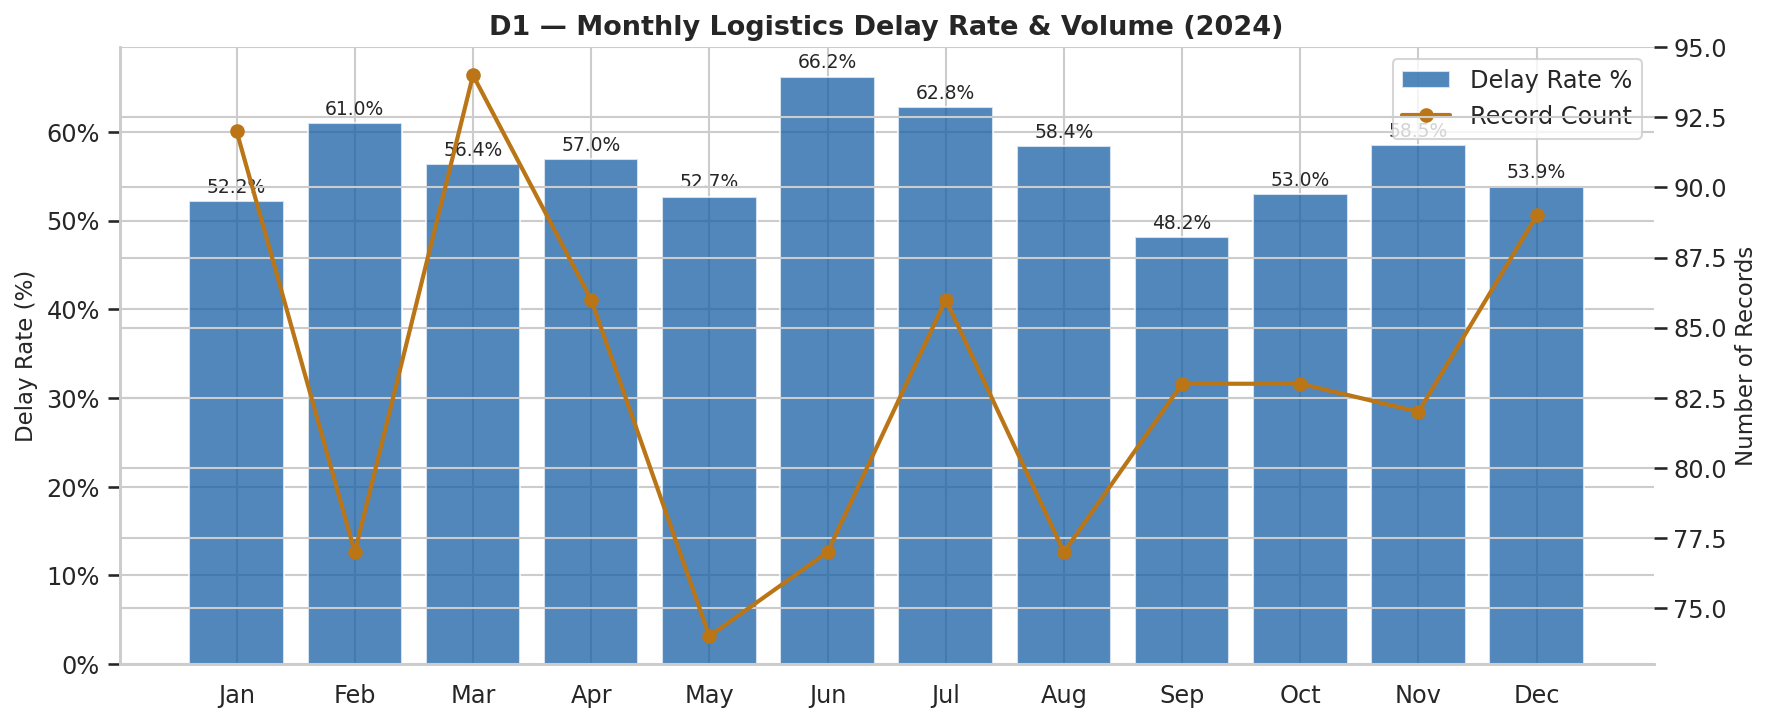

  ✓ saved  ./outputs/D1_monthly_delay_rate.png


In [5]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = (df.groupby("MonthName")["Logistics_Delay"]
             .agg(["mean","count"])
             .reindex(month_order).dropna().reset_index())
monthly.columns = ["Month","Delay_Rate","Count"]
monthly["Delay_Pct"] = monthly["Delay_Rate"] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(monthly["Month"], monthly["Delay_Pct"],
               color=PALETTE["primary"], alpha=0.75, label="Delay Rate %")
ax2 = ax1.twinx()
ax2.plot(monthly["Month"], monthly["Count"],
         color=PALETTE["warning"], marker="o", linewidth=2, label="Record Count")
ax1.set_ylabel("Delay Rate (%)")
ax2.set_ylabel("Number of Records")
ax1.set_title("D1 — Monthly Logistics Delay Rate & Volume (2024)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, pct in zip(bars, monthly["Delay_Pct"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")
save("D1_monthly_delay_rate")

### D2 · Per-Asset Delay Frequency & Average Waiting Time

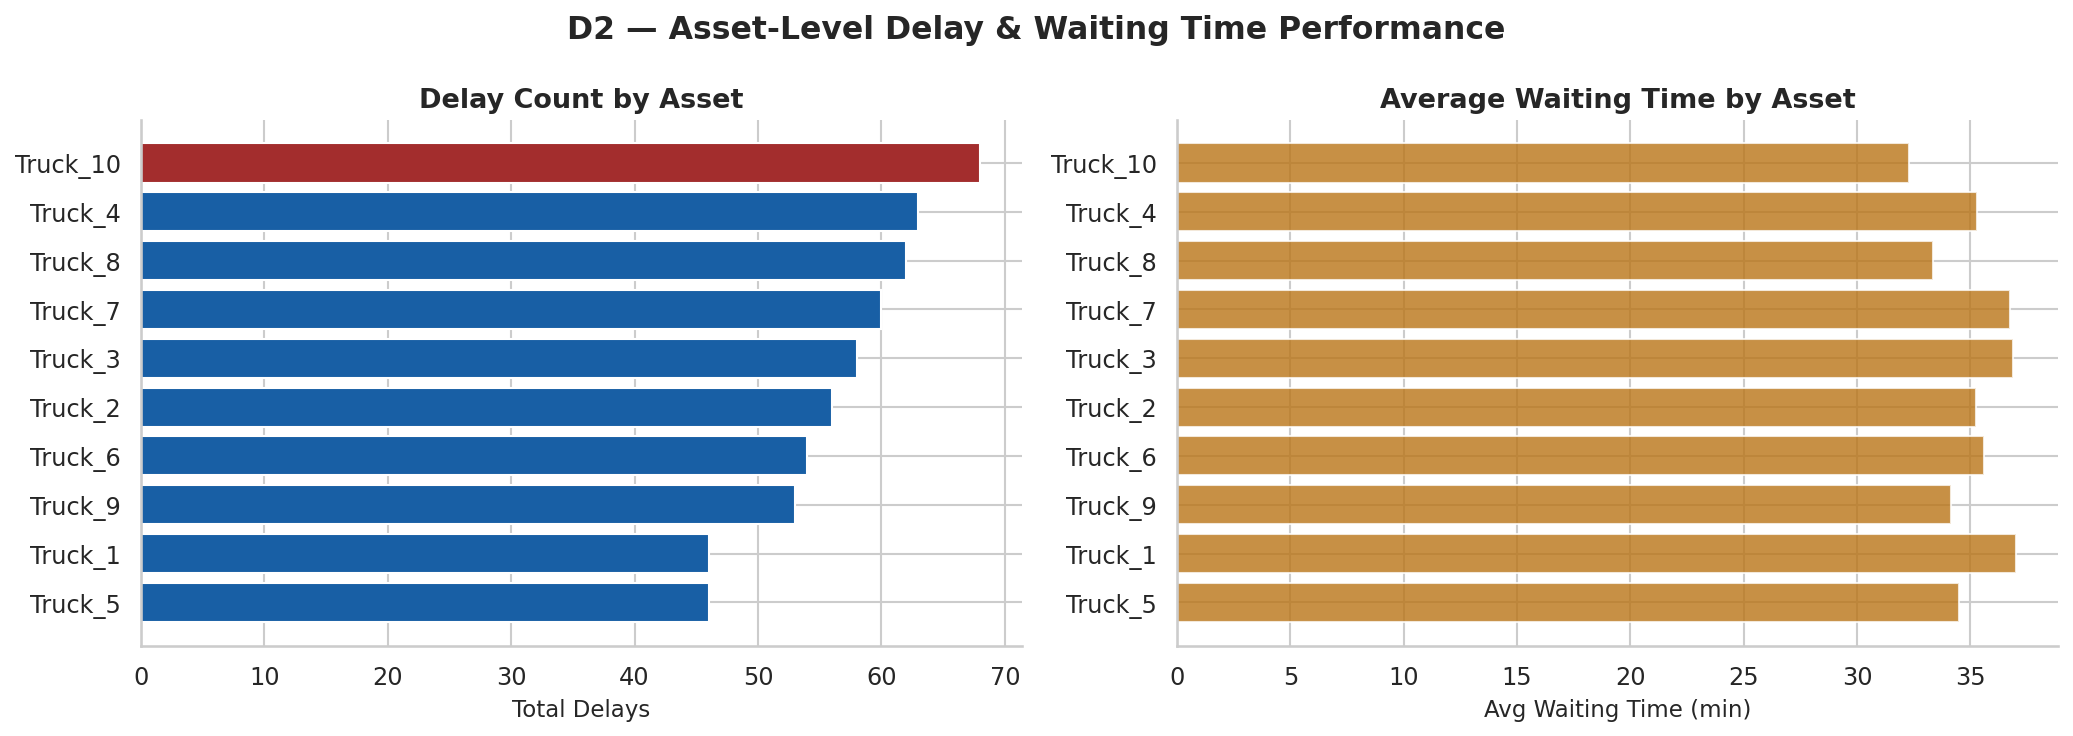

  ✓ saved  ./outputs/D2_asset_delay_performance.png


In [6]:
asset_stats = (df.groupby("Asset_ID")
                 .agg(Delay_Count=("Logistics_Delay","sum"),
                      Avg_Wait   =("Waiting_Time","mean"),
                      Total      =("Logistics_Delay","count"))
                 .assign(Delay_Rate=lambda x: x.Delay_Count/x.Total*100)
                 .sort_values("Delay_Count", ascending=False)
                 .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c = [PALETTE["danger"] if i == 0 else PALETTE["primary"] for i in range(len(asset_stats))]
axes[0].barh(asset_stats["Asset_ID"], asset_stats["Delay_Count"], color=c)
axes[0].set_xlabel("Total Delays")
axes[0].set_title("Delay Count by Asset")
axes[0].invert_yaxis()

axes[1].barh(asset_stats["Asset_ID"], asset_stats["Avg_Wait"],
             color=PALETTE["warning"], alpha=0.8)
axes[1].set_xlabel("Avg Waiting Time (min)")
axes[1].set_title("Average Waiting Time by Asset")
axes[1].invert_yaxis()
fig.suptitle("D2 — Asset-Level Delay & Waiting Time Performance", fontweight="bold")
save("D2_asset_delay_performance")

### D3 · Shipment Status Distribution

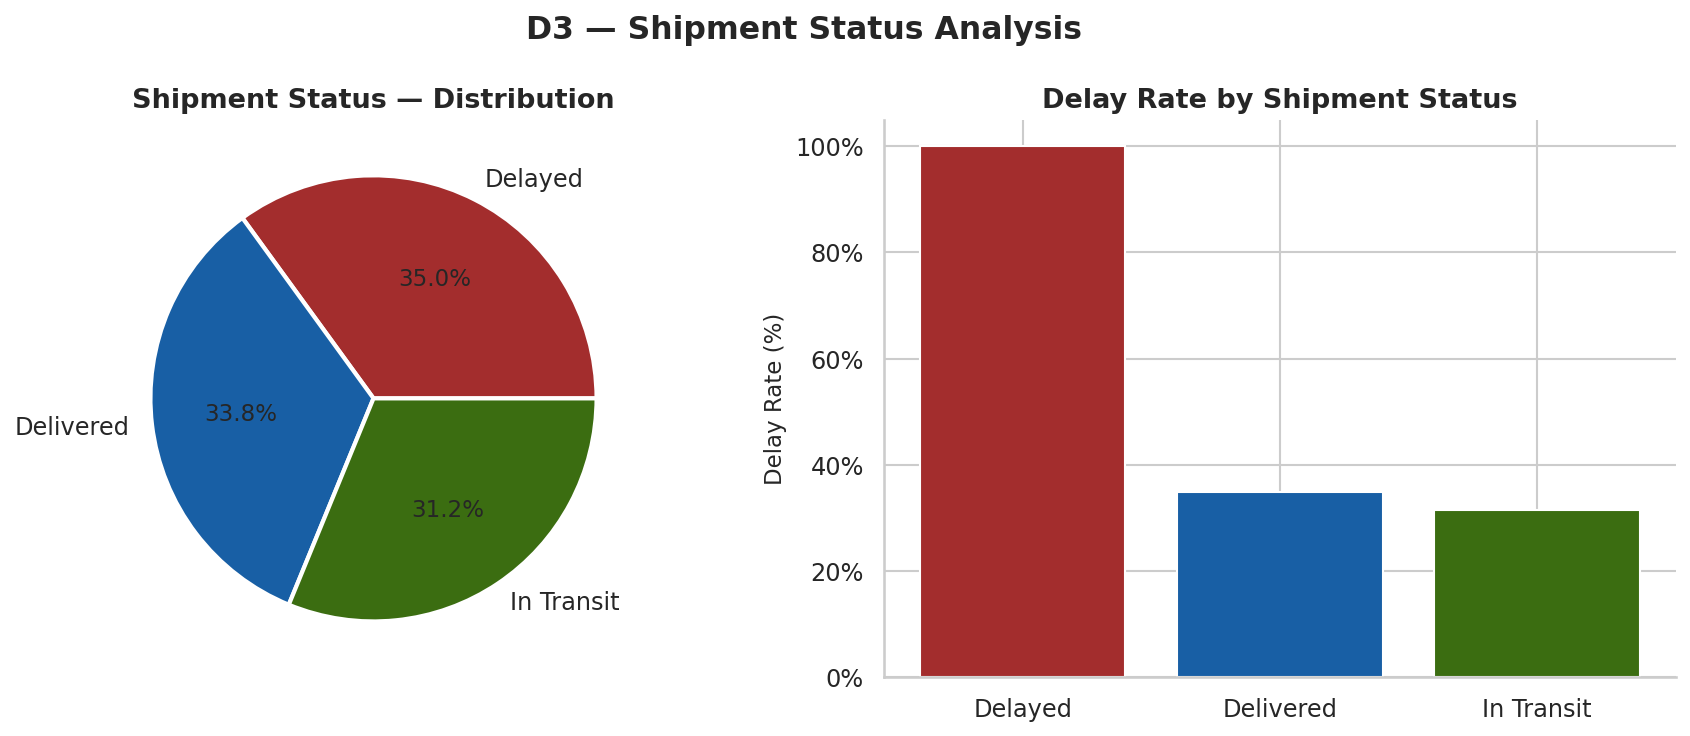

  ✓ saved  ./outputs/D3_shipment_status.png


In [7]:
status_counts = df["Shipment_Status"].value_counts()
colors = [PALETTE["danger"], PALETTE["primary"], PALETTE["success"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
wedges, texts, autotexts = axes[0].pie(
    status_counts.values, labels=status_counts.index,
    autopct="%1.1f%%", colors=colors,
    wedgeprops={"edgecolor":"white","linewidth":2})
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title("Shipment Status — Distribution")

status_delay = df.groupby("Shipment_Status")["Logistics_Delay"].mean() * 100
axes[1].bar(status_delay.index, status_delay.values,
            color=[PALETTE["danger"], PALETTE["primary"], PALETTE["success"]])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title("Delay Rate by Shipment Status")
axes[1].set_ylabel("Delay Rate (%)")
fig.suptitle("D3 — Shipment Status Analysis", fontweight="bold")
save("D3_shipment_status")

### D4 · Traffic Condition Impact

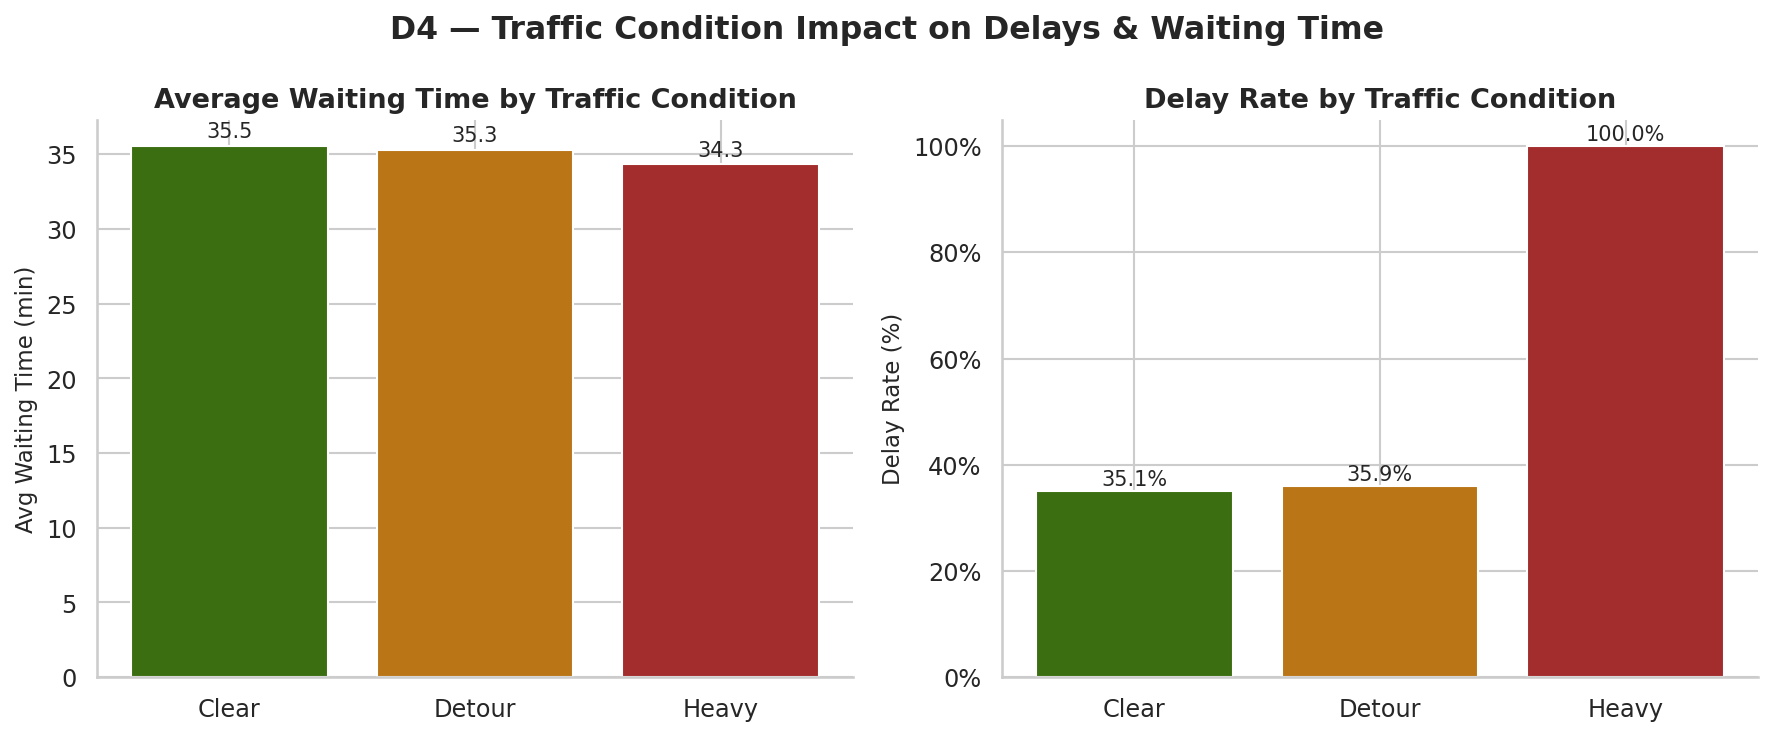

  ✓ saved  ./outputs/D4_traffic_impact.png


In [8]:
traffic_stats = (df.groupby("Traffic_Status")
                   .agg(Avg_Wait  =("Waiting_Time","mean"),
                        Delay_Rate=("Logistics_Delay","mean"))
                   .reset_index())
traffic_stats["Delay_Pct"] = traffic_stats["Delay_Rate"] * 100
traffic_colors = {"Clear": PALETTE["success"], "Heavy": PALETTE["danger"],
                  "Detour": PALETTE["warning"]}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars_t = axes[0].bar(traffic_stats["Traffic_Status"], traffic_stats["Avg_Wait"],
                     color=[traffic_colors[t] for t in traffic_stats["Traffic_Status"]])
axes[0].set_ylabel("Avg Waiting Time (min)")
axes[0].set_title("Average Waiting Time by Traffic Condition")
for bar, val in zip(bars_t, traffic_stats["Avg_Wait"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=10)

bars_d = axes[1].bar(traffic_stats["Traffic_Status"], traffic_stats["Delay_Pct"],
                     color=[traffic_colors[t] for t in traffic_stats["Traffic_Status"]])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylabel("Delay Rate (%)")
axes[1].set_title("Delay Rate by Traffic Condition")
for bar, val in zip(bars_d, traffic_stats["Delay_Pct"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
fig.suptitle("D4 — Traffic Condition Impact on Delays & Waiting Time", fontweight="bold")
save("D4_traffic_impact")

### D5 · Delay Reasons — Frequency & Duration

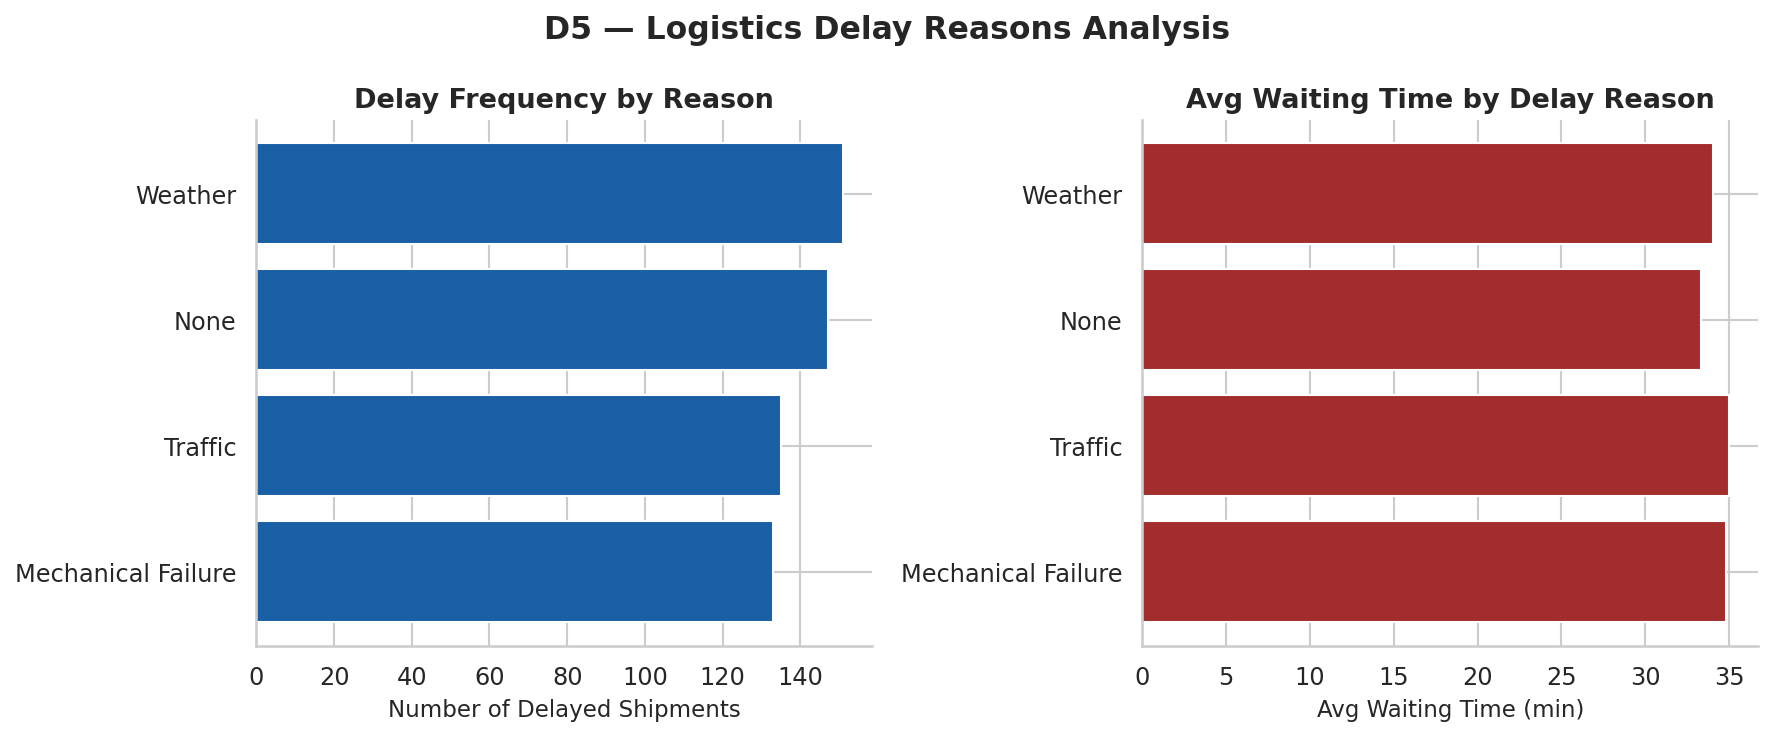

  ✓ saved  ./outputs/D5_delay_reasons.png


In [9]:
delayed      = df[df["Logistics_Delay"] == 1].copy()
reason_stats = (delayed.groupby("Logistics_Delay_Reason")
                       .agg(Count   =("Waiting_Time","count"),
                            Avg_Wait=("Waiting_Time","mean"))
                       .sort_values("Count", ascending=False)
                       .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(reason_stats["Logistics_Delay_Reason"], reason_stats["Count"],
             color=PALETTE["primary"])
axes[0].set_xlabel("Number of Delayed Shipments")
axes[0].set_title("Delay Frequency by Reason")
axes[0].invert_yaxis()

axes[1].barh(reason_stats["Logistics_Delay_Reason"], reason_stats["Avg_Wait"],
             color=PALETTE["danger"])
axes[1].set_xlabel("Avg Waiting Time (min)")
axes[1].set_title("Avg Waiting Time by Delay Reason")
axes[1].invert_yaxis()
fig.suptitle("D5 — Logistics Delay Reasons Analysis", fontweight="bold")
save("D5_delay_reasons")

---
## Section B · Descriptive — Environmental & IoT Conditions

### D6 · Temperature & Humidity Correlation with Delay

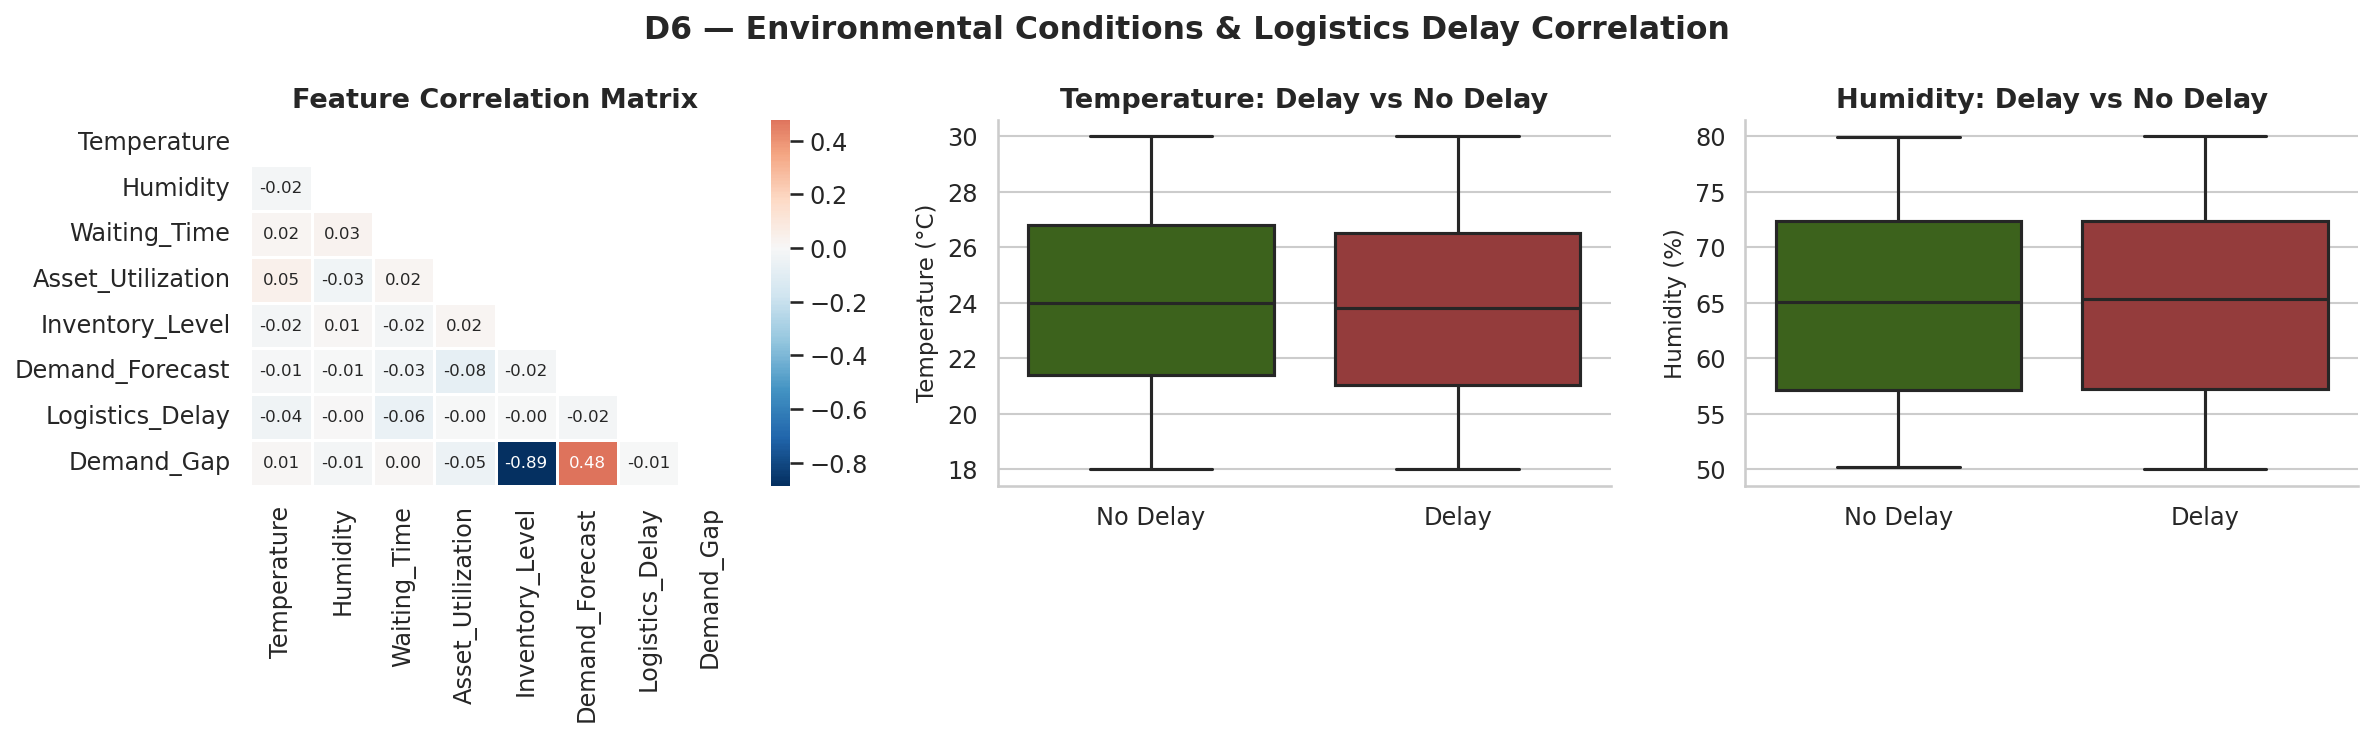

  ✓ saved  ./outputs/D6_environmental_correlation.png

📊 Independent samples t-tests:
  Temperature: No Delay μ=24.04, Delay μ=23.78, t=1.203, p=0.2291  ✗ not significant
  Humidity: No Delay μ=65.05, Delay μ=65.04, t=0.016, p=0.9873  ✗ not significant


In [10]:
num_cols = ["Temperature","Humidity","Waiting_Time","Asset_Utilization",
            "Inventory_Level","Demand_Forecast","Logistics_Delay","Demand_Gap"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, annot_kws={"size":8})
axes[0].set_title("Feature Correlation Matrix")

sns.boxplot(data=df, x="Delay_Label", y="Temperature", ax=axes[1],
            palette={"No Delay": PALETTE["success"], "Delay": PALETTE["danger"]},
            order=["No Delay","Delay"])
axes[1].set_title("Temperature: Delay vs No Delay")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_xlabel("")

sns.boxplot(data=df, x="Delay_Label", y="Humidity", ax=axes[2],
            palette={"No Delay": PALETTE["success"], "Delay": PALETTE["danger"]},
            order=["No Delay","Delay"])
axes[2].set_title("Humidity: Delay vs No Delay")
axes[2].set_ylabel("Humidity (%)")
axes[2].set_xlabel("")

fig.suptitle("D6 — Environmental Conditions & Logistics Delay Correlation", fontweight="bold")
save("D6_environmental_correlation")

print("\n📊 Independent samples t-tests:")
for col in ["Temperature", "Humidity"]:
    grp0 = df[df["Logistics_Delay"]==0][col]
    grp1 = df[df["Logistics_Delay"]==1][col]
    t, p = stats.ttest_ind(grp0, grp1)
    sig  = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {col}: No Delay μ={grp0.mean():.2f}, Delay μ={grp1.mean():.2f}, "
          f"t={t:.3f}, p={p:.4f}  {sig}")

### D7 · Asset Utilisation — Delayed vs Non-Delayed

Utilisation statistics by delay status:


,count,mean,std,min,25%,50%,75%,max
Delay_Label,,,,,,,,
Delay,566.0,79.57,11.75,60.1,69.40,79.0,89.30,100.0
No Delay,434.0,79.64,11.49,60.0,69.62,80.0,89.57,100.0


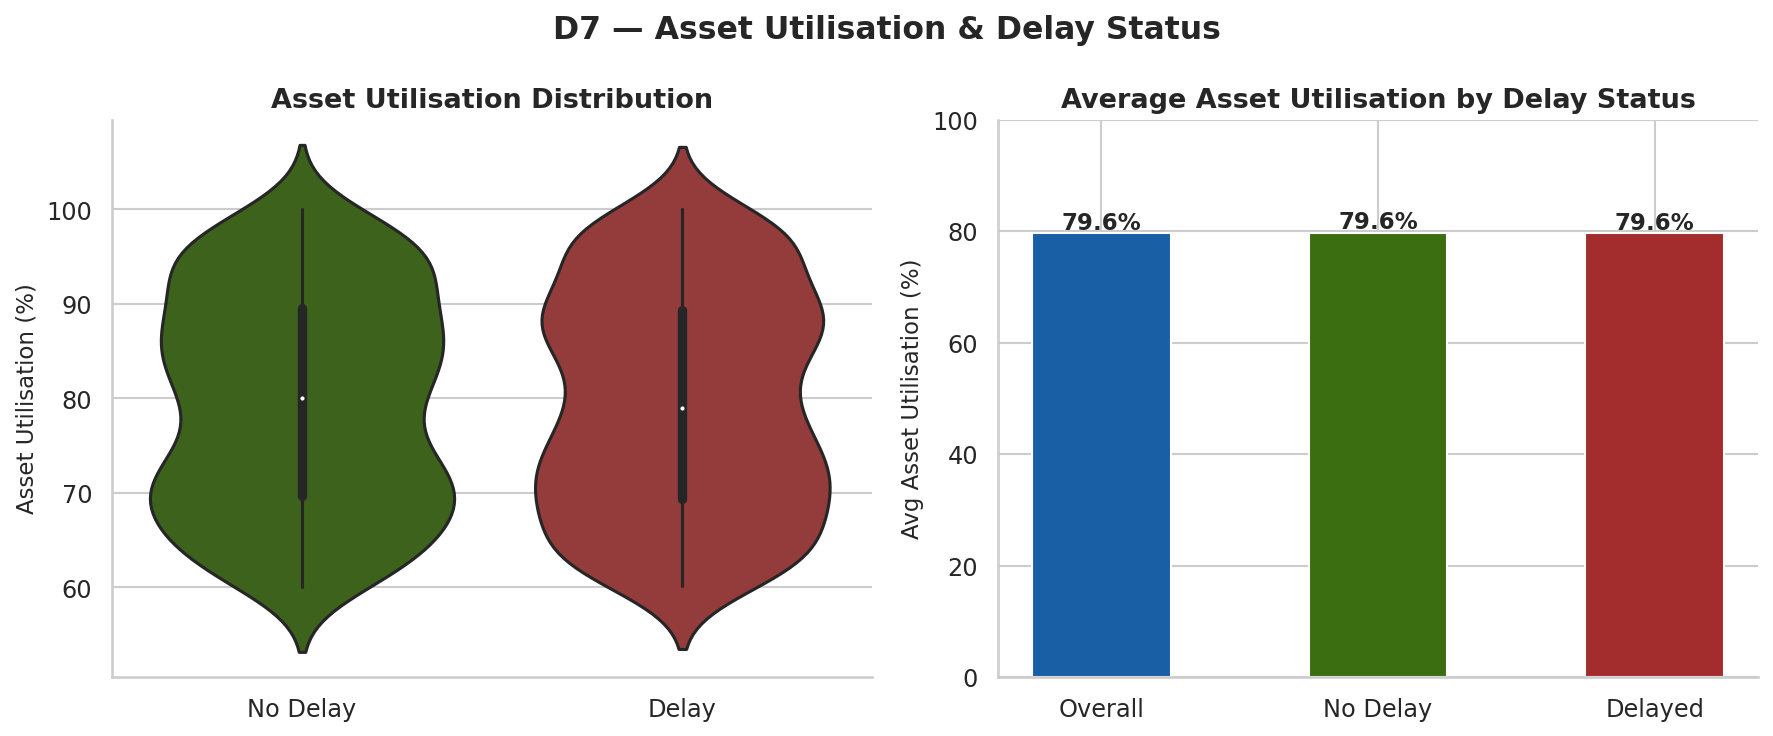

  ✓ saved  ./outputs/D7_asset_utilisation.png


In [11]:
print("Utilisation statistics by delay status:")
display(df.groupby("Delay_Label")["Asset_Utilization"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.violinplot(data=df, x="Delay_Label", y="Asset_Utilization", ax=axes[0],
               palette={"No Delay": PALETTE["success"], "Delay": PALETTE["danger"]},
               order=["No Delay","Delay"], inner="box")
axes[0].set_title("Asset Utilisation Distribution")
axes[0].set_ylabel("Asset Utilisation (%)")
axes[0].set_xlabel("")

overall  = df["Asset_Utilization"].mean()
no_delay = df[df["Logistics_Delay"]==0]["Asset_Utilization"].mean()
delay_v  = df[df["Logistics_Delay"]==1]["Asset_Utilization"].mean()
axes[1].bar(["Overall","No Delay","Delayed"], [overall, no_delay, delay_v],
            color=[PALETTE["primary"], PALETTE["success"], PALETTE["danger"]], width=0.5)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Avg Asset Utilisation (%)")
axes[1].set_title("Average Asset Utilisation by Delay Status")
for i, v in enumerate([overall, no_delay, delay_v]):
    axes[1].text(i, v+0.8, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
fig.suptitle("D7 — Asset Utilisation & Delay Status", fontweight="bold")
save("D7_asset_utilisation")

### D8 · Inventory Level vs Shipment Status & Delay

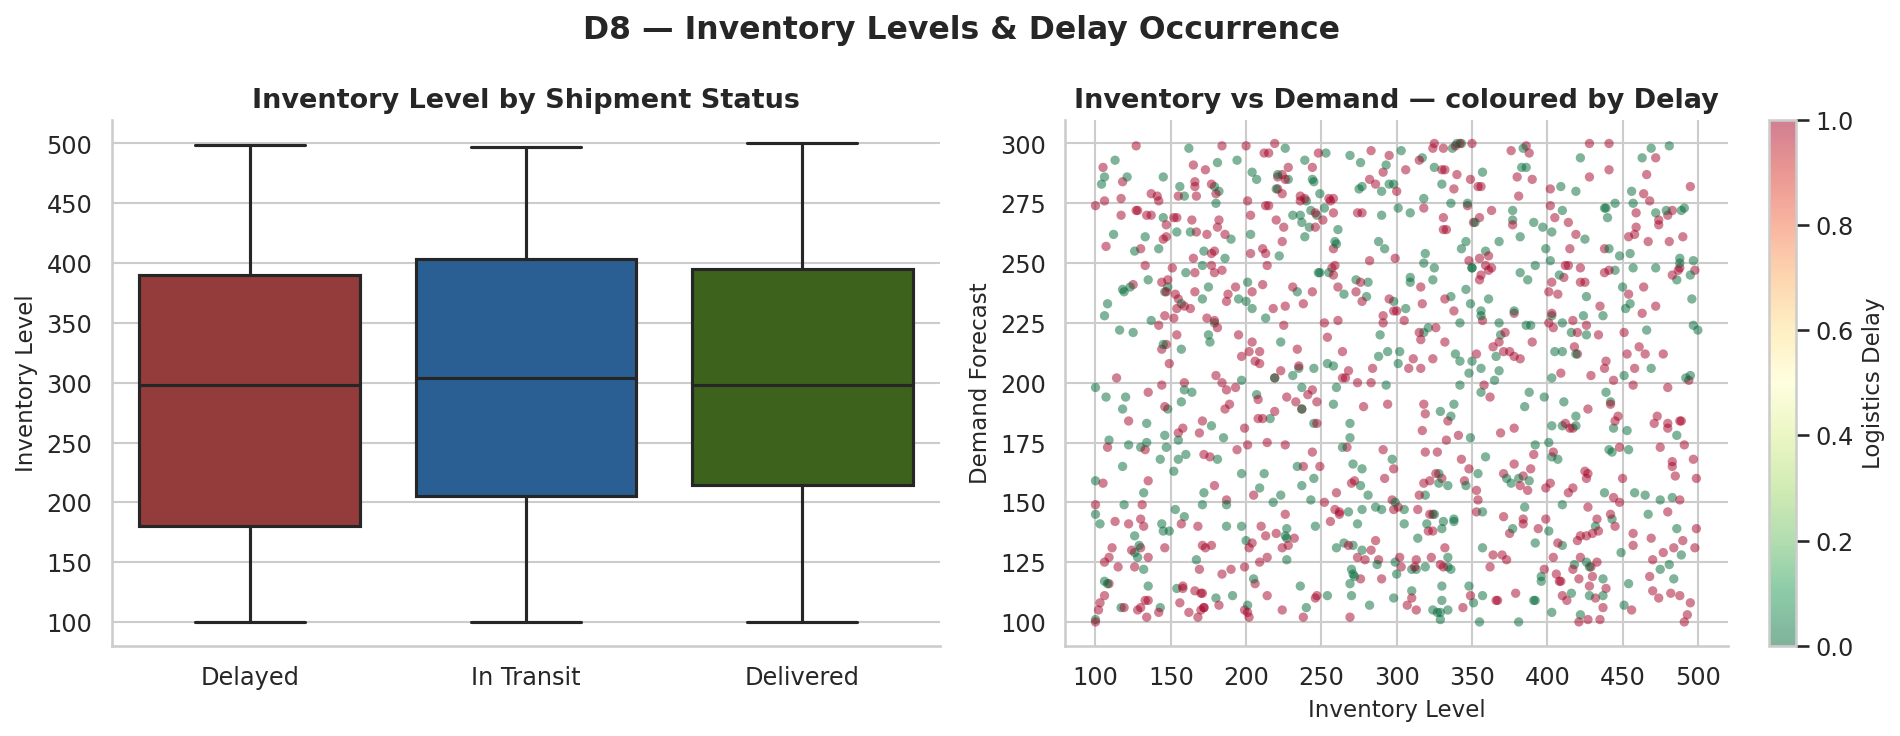

  ✓ saved  ./outputs/D8_inventory_vs_delay.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="Shipment_Status", y="Inventory_Level", ax=axes[0],
            palette={"Delayed": PALETTE["danger"],
                     "In Transit": PALETTE["primary"],
                     "Delivered": PALETTE["success"]})
axes[0].set_title("Inventory Level by Shipment Status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Inventory Level")

sc = axes[1].scatter(df["Inventory_Level"], df["Demand_Forecast"],
                     c=df["Logistics_Delay"], cmap="RdYlGn_r",
                     alpha=0.5, s=20, edgecolors="none")
plt.colorbar(sc, ax=axes[1], label="Logistics Delay")
axes[1].set_xlabel("Inventory Level")
axes[1].set_ylabel("Demand Forecast")
axes[1].set_title("Inventory vs Demand — coloured by Delay")
fig.suptitle("D8 — Inventory Levels & Delay Occurrence", fontweight="bold")
save("D8_inventory_vs_delay")

---
## Section C · Descriptive — Demand, Transactions & Geography

### D9 · Geographic Delay Hotspots

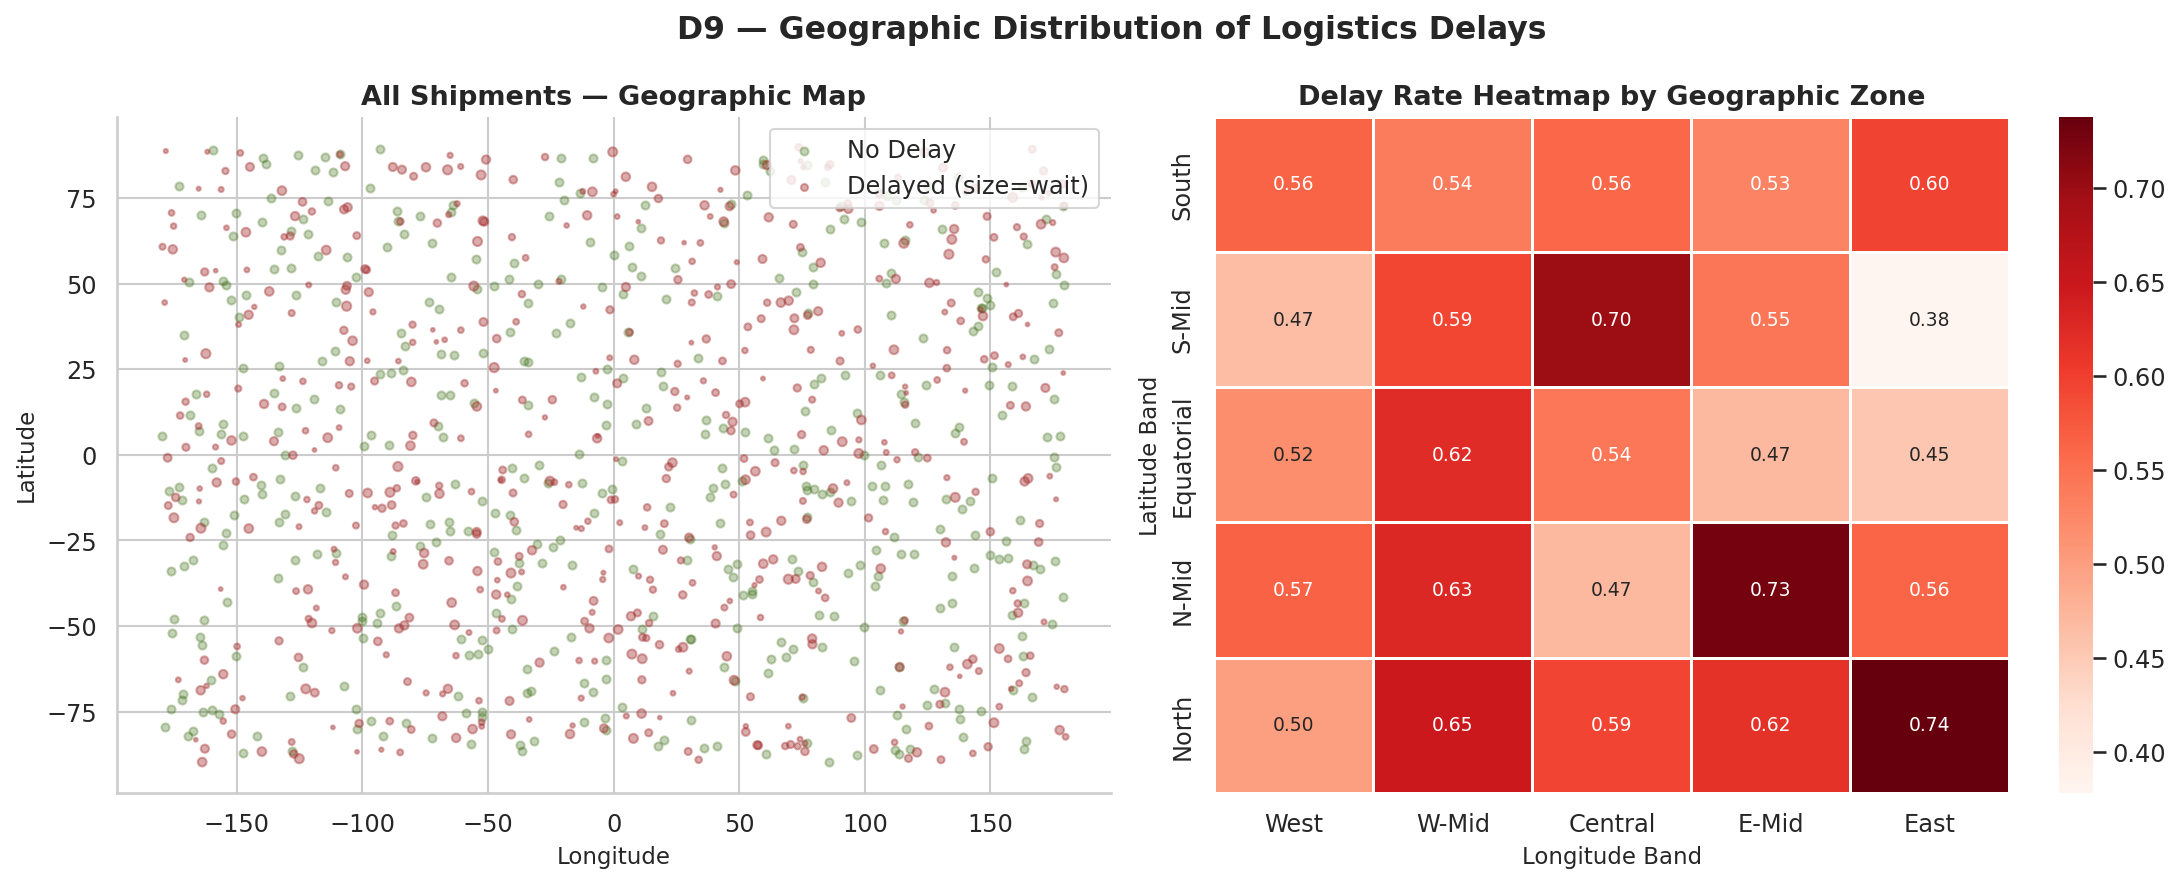

  ✓ saved  ./outputs/D9_geographic_hotspots.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
delayed_geo     = df[df["Logistics_Delay"]==1]
non_delayed_geo = df[df["Logistics_Delay"]==0]

axes[0].scatter(non_delayed_geo["Longitude"], non_delayed_geo["Latitude"],
                c=PALETTE["success"], alpha=0.3, s=15, label="No Delay")
axes[0].scatter(delayed_geo["Longitude"], delayed_geo["Latitude"],
                c=PALETTE["danger"], alpha=0.4,
                s=delayed_geo["Waiting_Time"]/3, label="Delayed (size=wait)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("All Shipments — Geographic Map")
axes[0].legend(loc="upper right")

df["Lat_Band"] = pd.cut(df["Latitude"],  bins=5,
                         labels=["South","S-Mid","Equatorial","N-Mid","North"])
df["Lon_Band"] = pd.cut(df["Longitude"], bins=5,
                         labels=["West","W-Mid","Central","E-Mid","East"])
geo_pivot = df.pivot_table(index="Lat_Band", columns="Lon_Band",
                            values="Logistics_Delay", aggfunc="mean")
sns.heatmap(geo_pivot, annot=True, fmt=".2f", cmap="Reds",
            ax=axes[1], linewidths=0.5, annot_kws={"size":9})
axes[1].set_title("Delay Rate Heatmap by Geographic Zone")
axes[1].set_xlabel("Longitude Band")
axes[1].set_ylabel("Latitude Band")
fig.suptitle("D9 — Geographic Distribution of Logistics Delays", fontweight="bold")
save("D9_geographic_hotspots")

### D10 · Demand Gap Analysis

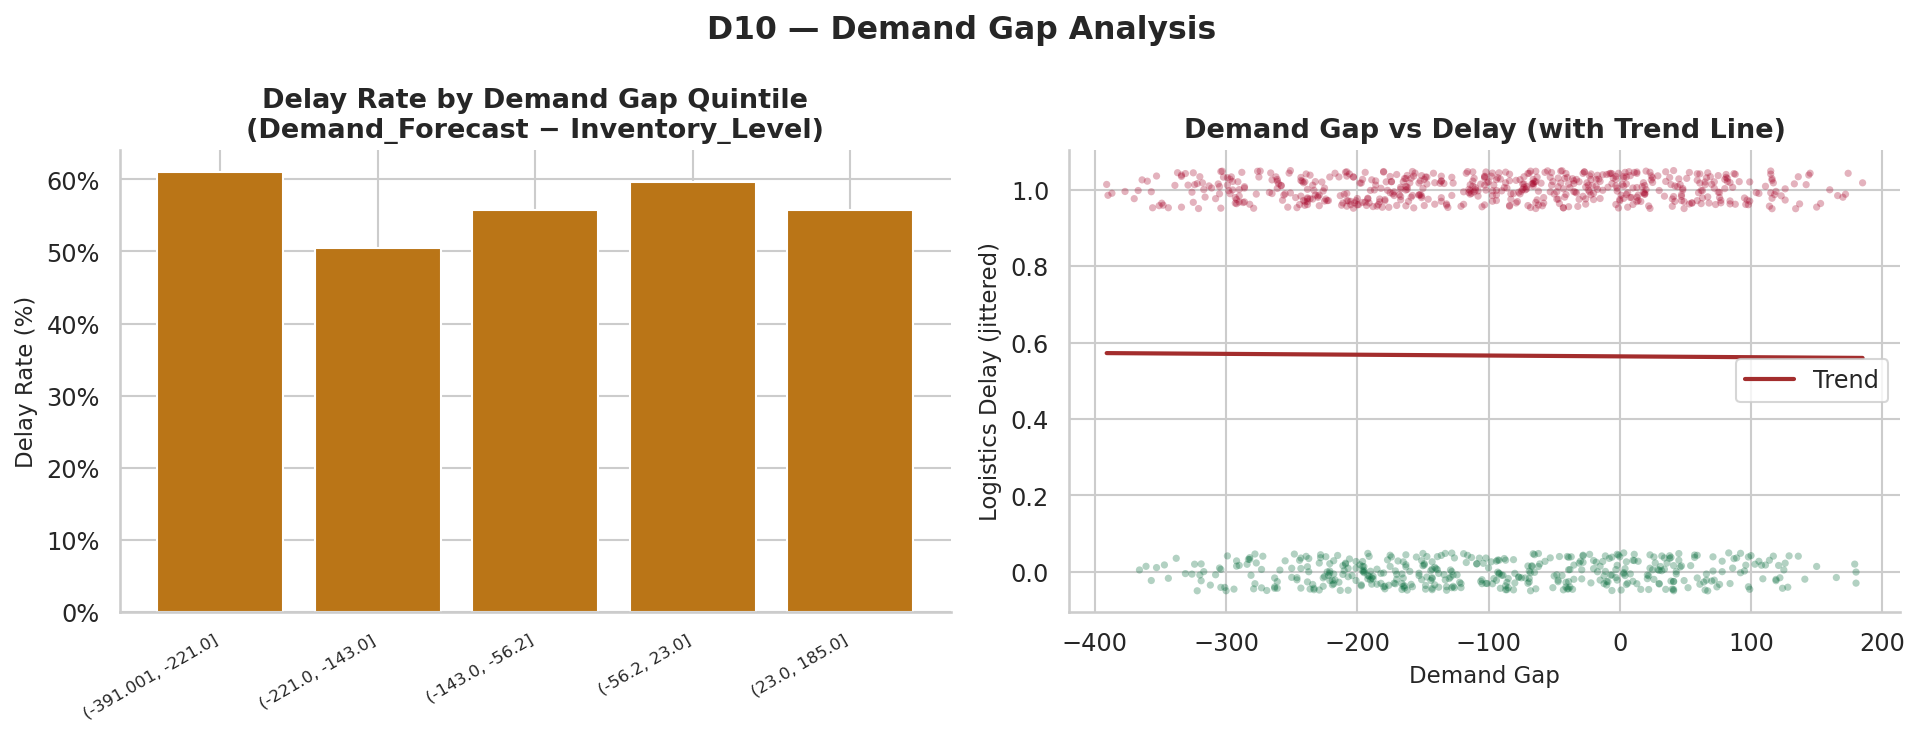

  ✓ saved  ./outputs/D10_demand_gap.png
Pearson correlation  Demand_Gap ↔ Logistics_Delay: -0.0057


In [14]:
gap_delay = df.groupby(pd.qcut(df["Demand_Gap"], q=5, duplicates="drop"))["Logistics_Delay"].mean() * 100
gap_delay.index = [str(i) for i in gap_delay.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(len(gap_delay)), gap_delay.values, color=PALETTE["warning"])
axes[0].set_xticks(range(len(gap_delay)))
axes[0].set_xticklabels(gap_delay.index, rotation=30, ha="right", fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_ylabel("Delay Rate (%)")
axes[0].set_title("Delay Rate by Demand Gap Quintile\n(Demand_Forecast − Inventory_Level)")

axes[1].scatter(df["Demand_Gap"], df["Logistics_Delay"]+np.random.uniform(-0.05,0.05,len(df)),
                c=df["Logistics_Delay"], cmap="RdYlGn_r", alpha=0.3, s=12, edgecolors="none")
z = np.polyfit(df["Demand_Gap"], df["Logistics_Delay"], 1)
x_line = np.linspace(df["Demand_Gap"].min(), df["Demand_Gap"].max(), 200)
axes[1].plot(x_line, np.polyval(z, x_line), color=PALETTE["danger"],
             linewidth=2, label="Trend")
axes[1].set_xlabel("Demand Gap")
axes[1].set_ylabel("Logistics Delay (jittered)")
axes[1].set_title("Demand Gap vs Delay (with Trend Line)")
axes[1].legend()
fig.suptitle("D10 — Demand Gap Analysis", fontweight="bold")
save("D10_demand_gap")

corr_val = df["Demand_Gap"].corr(df["Logistics_Delay"])
print(f"Pearson correlation  Demand_Gap ↔ Logistics_Delay: {corr_val:.4f}")

### D11 · User Behaviour vs Delay

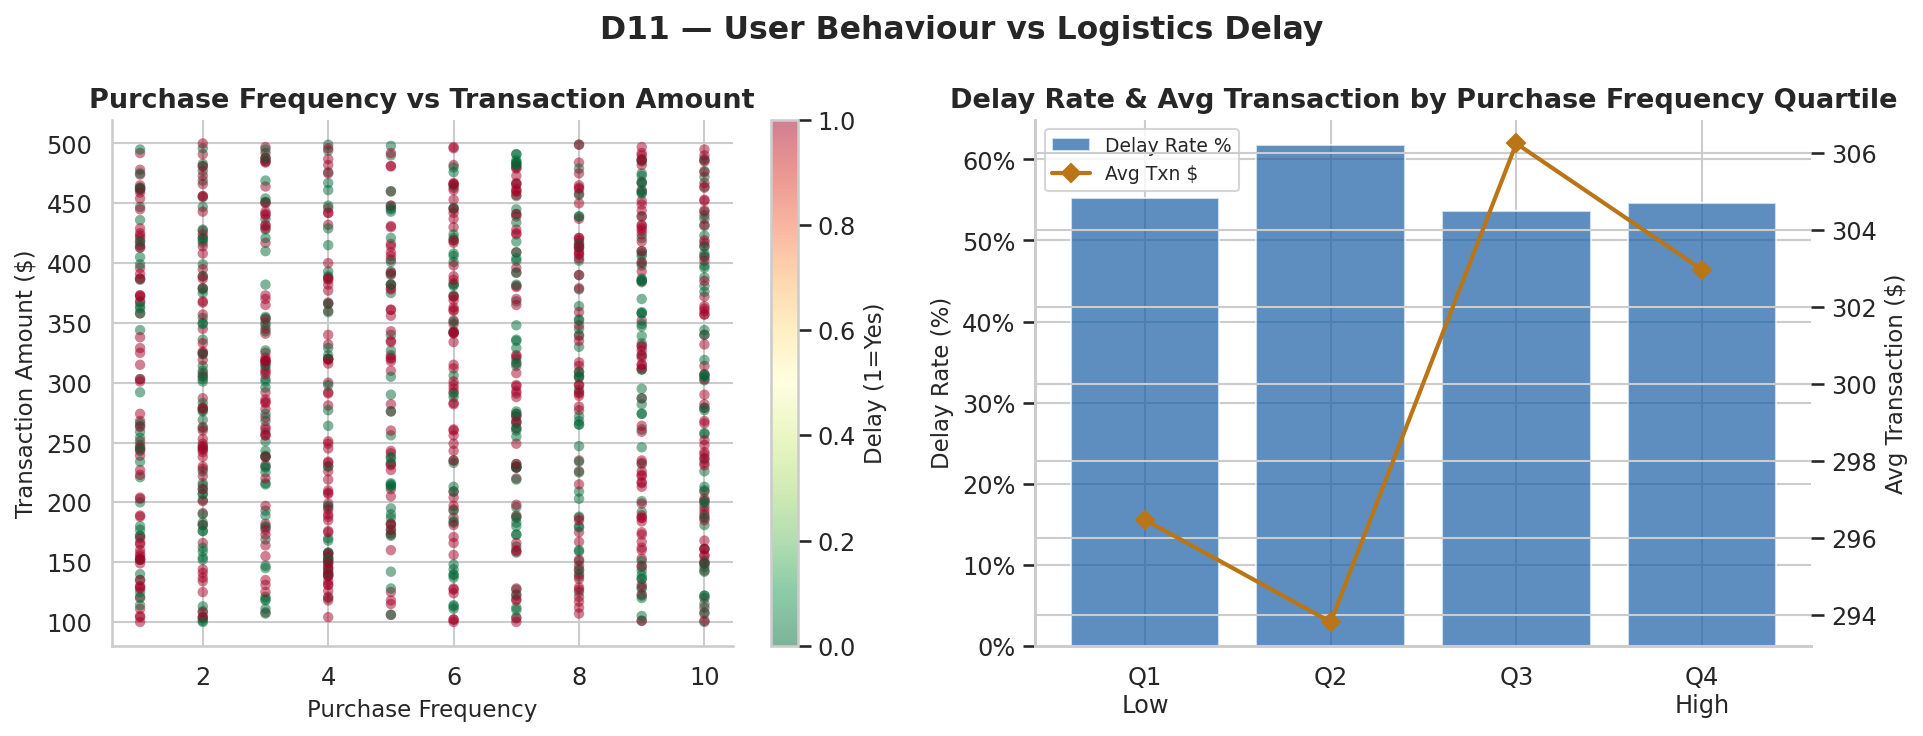

  ✓ saved  ./outputs/D11_user_behaviour.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(df["User_Purchase_Frequency"], df["User_Transaction_Amount"],
                     c=df["Logistics_Delay"], cmap="RdYlGn_r",
                     alpha=0.5, s=25, edgecolors="none")
plt.colorbar(sc, ax=axes[0], label="Delay (1=Yes)")
axes[0].set_xlabel("Purchase Frequency")
axes[0].set_ylabel("Transaction Amount ($)")
axes[0].set_title("Purchase Frequency vs Transaction Amount")

df["Freq_Quartile"] = pd.qcut(df["User_Purchase_Frequency"], q=4,
                               labels=["Q1\nLow","Q2","Q3","Q4\nHigh"])
freq_stats = df.groupby("Freq_Quartile", observed=True).agg(
    Delay_Pct=("Logistics_Delay", lambda x: x.mean()*100),
    Avg_Txn  =("User_Transaction_Amount","mean")).reset_index()

ax2b = axes[1].twinx()
axes[1].bar(freq_stats["Freq_Quartile"], freq_stats["Delay_Pct"],
            color=PALETTE["primary"], alpha=0.7, label="Delay Rate %")
ax2b.plot(freq_stats["Freq_Quartile"], freq_stats["Avg_Txn"],
          color=PALETTE["warning"], marker="D", linewidth=2, label="Avg Txn $")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylabel("Delay Rate (%)")
ax2b.set_ylabel("Avg Transaction ($)")
axes[1].set_title("Delay Rate & Avg Transaction by Purchase Frequency Quartile")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=9)
fig.suptitle("D11 — User Behaviour vs Logistics Delay", fontweight="bold")
save("D11_user_behaviour")

### D12 · Hour-of-Day Delay Rate

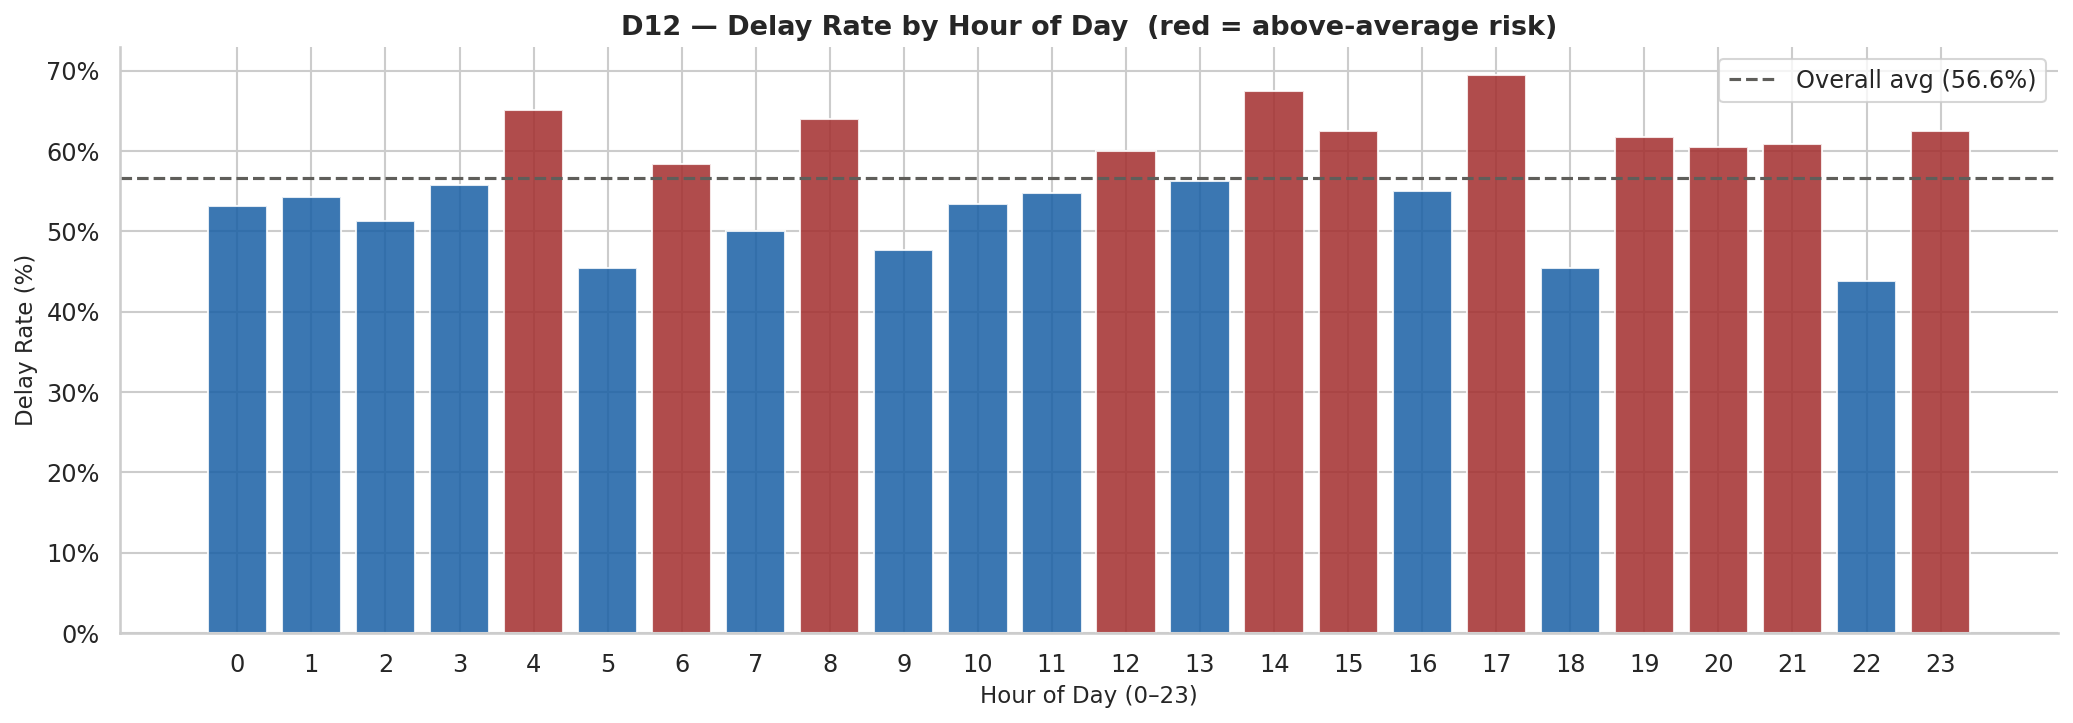

  ✓ saved  ./outputs/D12_hourly_delay_rate.png


In [16]:
hourly = df.groupby("Hour").agg(
    Delay_Rate=("Logistics_Delay","mean"),
    Count     =("Logistics_Delay","count")).reset_index()
hourly["Delay_Pct"] = hourly["Delay_Rate"] * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors_h = [PALETTE["danger"] if p > hourly["Delay_Pct"].mean() else PALETTE["primary"]
            for p in hourly["Delay_Pct"]]
ax.bar(hourly["Hour"], hourly["Delay_Pct"], color=colors_h, alpha=0.85)
ax.axhline(hourly["Delay_Pct"].mean(), color=PALETTE["muted"], linestyle="--",
           linewidth=1.5, label=f"Overall avg ({hourly['Delay_Pct'].mean():.1f}%)")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Delay Rate (%)")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("D12 — Delay Rate by Hour of Day  (red = above-average risk)")
ax.legend()
save("D12_hourly_delay_rate")

### D13 · Waiting Time Distribution by Traffic Condition

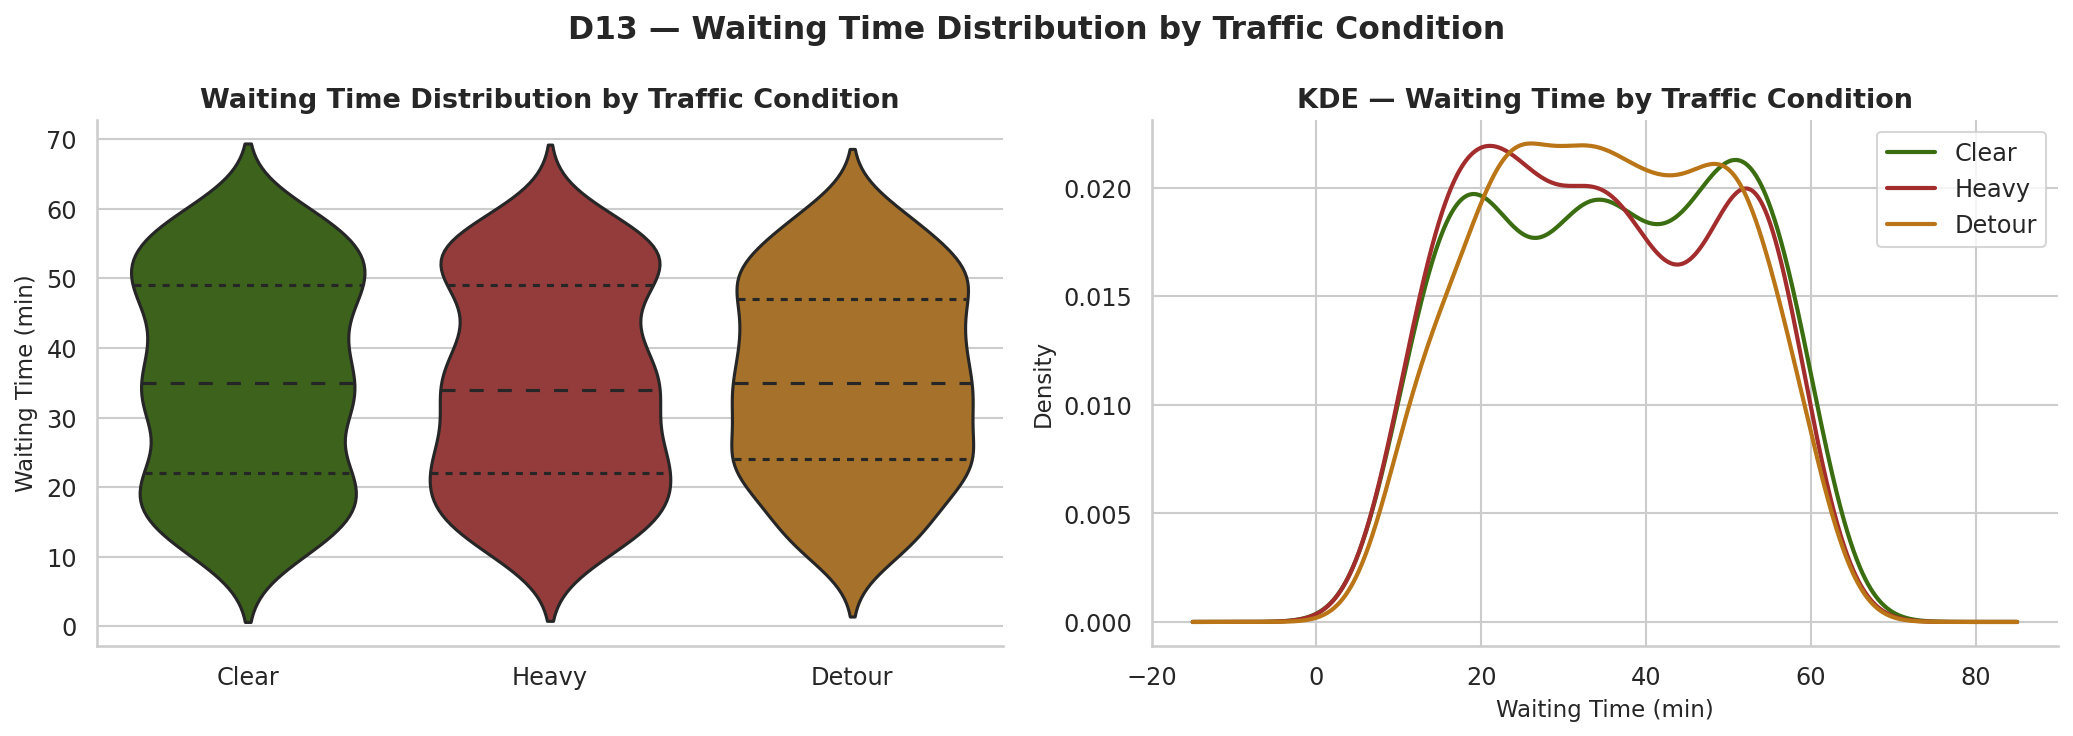

  ✓ saved  ./outputs/D13_waiting_time_distribution.png

📊 Waiting Time Percentiles by Traffic Condition:
  Clear: P50=35  P90=56  P99=60  mean=35.5
  Heavy: P50=34  P90=54  P99=60  mean=34.3
  Detour: P50=35  P90=54  P99=60  mean=35.3


In [17]:
traffic_order  = ["Clear", "Heavy", "Detour"]
palette_traffic = {"Clear": PALETTE["success"], "Heavy": PALETTE["danger"],
                   "Detour": PALETTE["warning"]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x="Traffic_Status", y="Waiting_Time", order=traffic_order,
               palette=palette_traffic, ax=axes[0], inner="quartile")
axes[0].set_title("Waiting Time Distribution by Traffic Condition")
axes[0].set_ylabel("Waiting Time (min)")
axes[0].set_xlabel("")

for traffic in traffic_order:
    grp = df[df["Traffic_Status"]==traffic]["Waiting_Time"]
    grp.plot.kde(ax=axes[1], label=traffic, color=palette_traffic[traffic], linewidth=2)
axes[1].set_xlabel("Waiting Time (min)")
axes[1].set_ylabel("Density")
axes[1].set_title("KDE — Waiting Time by Traffic Condition")
axes[1].legend()
fig.suptitle("D13 — Waiting Time Distribution by Traffic Condition", fontweight="bold")
save("D13_waiting_time_distribution")

print("\n📊 Waiting Time Percentiles by Traffic Condition:")
for traffic in traffic_order:
    grp = df[df["Traffic_Status"]==traffic]["Waiting_Time"]
    print(f"  {traffic}: P50={grp.quantile(.5):.0f}  P90={grp.quantile(.9):.0f}  "
          f"P99={grp.quantile(.99):.0f}  mean={grp.mean():.1f}")

### D14 · Seasonal Asset Utilisation Trend

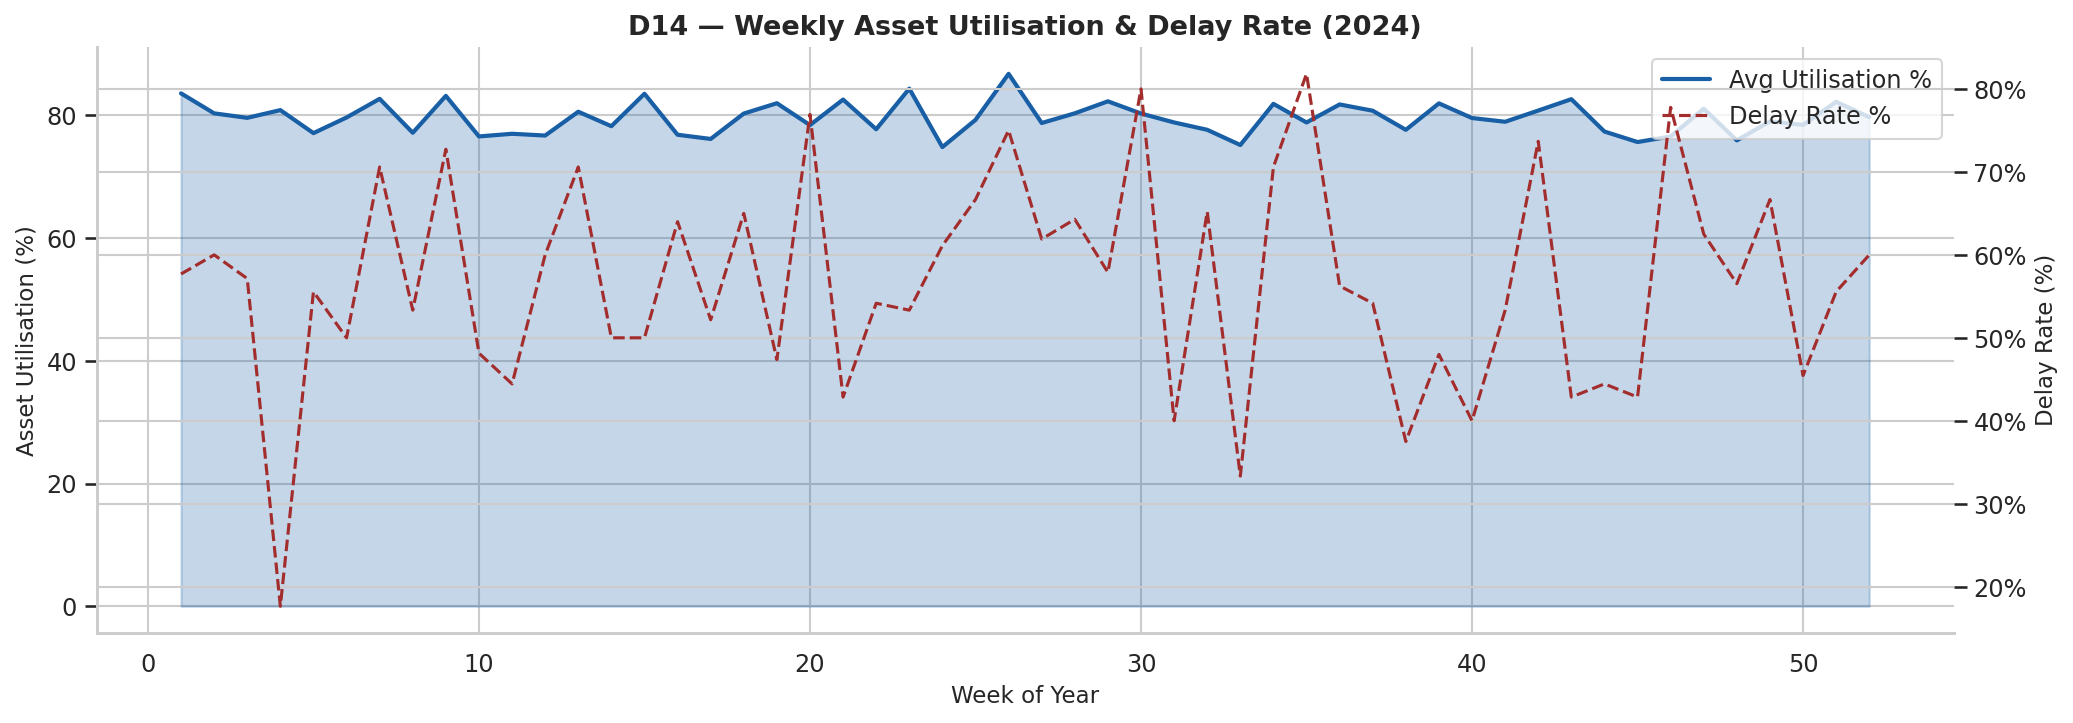

  ✓ saved  ./outputs/D14_seasonal_utilisation.png


In [18]:
weekly = df.groupby("Week").agg(
    Avg_Util  =("Asset_Utilization","mean"),
    Delay_Rate=("Logistics_Delay","mean")).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.fill_between(weekly["Week"], weekly["Avg_Util"], alpha=0.25, color=PALETTE["primary"])
ax1.plot(weekly["Week"], weekly["Avg_Util"],
         color=PALETTE["primary"], linewidth=2, label="Avg Utilisation %")
ax2.plot(weekly["Week"], weekly["Delay_Rate"]*100,
         color=PALETTE["danger"], linewidth=1.5, linestyle="--", label="Delay Rate %")
ax1.set_xlabel("Week of Year")
ax1.set_ylabel("Asset Utilisation (%)")
ax2.set_ylabel("Delay Rate (%)")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_title("D14 — Weekly Asset Utilisation & Delay Rate (2024)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper right")
save("D14_seasonal_utilisation")

### D15 · Traffic × Delay Reason Matrix

Average Waiting Time (min) — Traffic × Delay Reason:


Logistics_Delay_Reason,Mechanical Failure,None,Traffic,Weather
Traffic_Status,,,,
Clear,35.000000,34.300000,36.500000,36.400000
Detour,36.600000,35.500000,35.900000,33.600000
Heavy,36.300000,32.900000,35.400000,32.700000


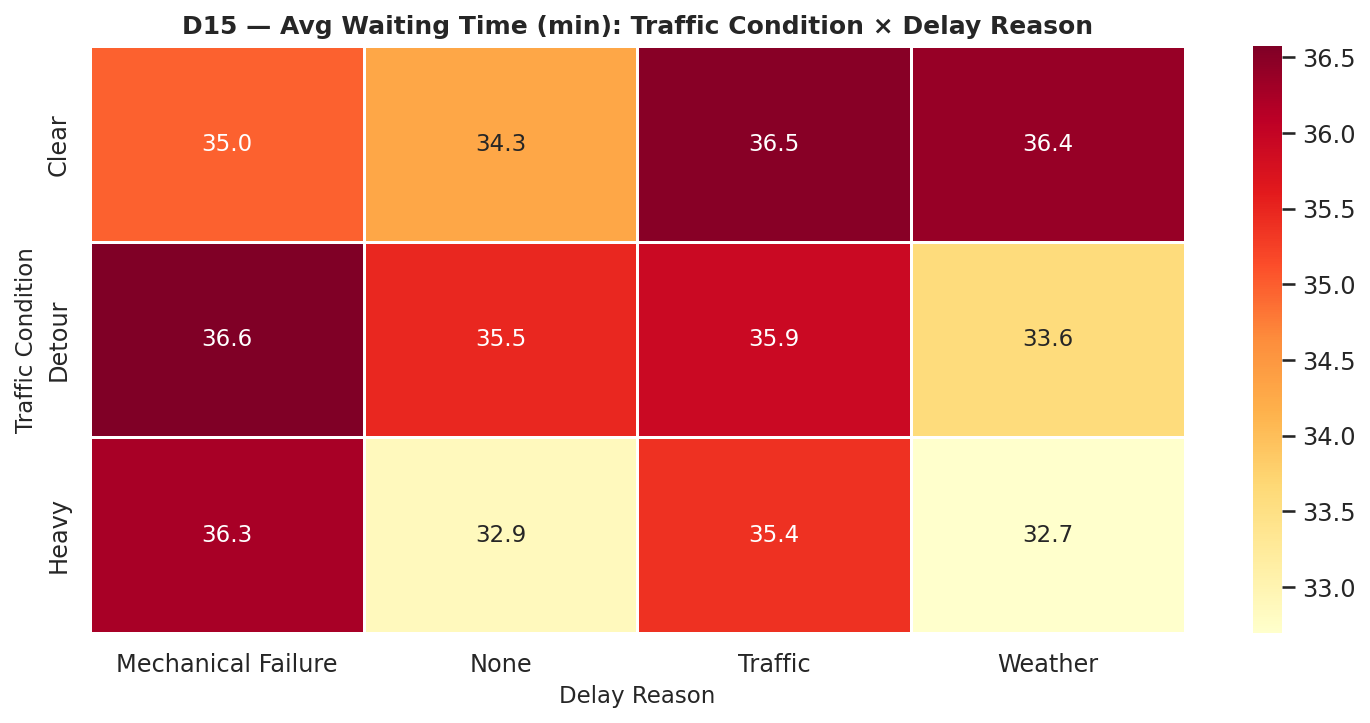

  ✓ saved  ./outputs/D15_traffic_reason_matrix.png


In [19]:
pivot_d15 = df.pivot_table(index="Traffic_Status", columns="Logistics_Delay_Reason",
                            values="Waiting_Time", aggfunc="mean")
print("Average Waiting Time (min) — Traffic × Delay Reason:")
display(pivot_d15.round(1).style.background_gradient(cmap="YlOrRd"))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_d15, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=ax, linewidths=0.5, annot_kws={"size":11})
ax.set_title("D15 — Avg Waiting Time (min): Traffic Condition × Delay Reason",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Delay Reason")
ax.set_ylabel("Traffic Condition")
save("D15_traffic_reason_matrix")

---
## Section D · Predictive Analysis
### Feature Engineering for ML

In [20]:
df_ml = df.copy()
le = LabelEncoder()
for col in ["Shipment_Status", "Traffic_Status", "Asset_ID"]:
    df_ml[col+"_enc"] = le.fit_transform(df_ml[col].astype(str))

FEATURE_COLS = [
    "Inventory_Level","Temperature","Humidity","Waiting_Time",
    "User_Transaction_Amount","User_Purchase_Frequency",
    "Asset_Utilization","Demand_Forecast","Demand_Gap",
    "Month","Hour","Shipment_Status_enc","Traffic_Status_enc","Asset_ID_enc"
]
PRE_DEPART_COLS = [
    "Inventory_Level","Temperature","Humidity",
    "User_Transaction_Amount","User_Purchase_Frequency",
    "Asset_Utilization","Demand_Forecast","Demand_Gap",
    "Month","Hour","Traffic_Status_enc","Asset_ID_enc"
]

X     = df_ml[FEATURE_COLS]
y     = df_ml["Logistics_Delay"]
X_pre = df_ml[PRE_DEPART_COLS]

X_tr,  X_te,  y_tr,  y_te  = train_test_split(X,     y, test_size=0.2, random_state=42, stratify=y)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_pre, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr);  X_te_s  = scaler.transform(X_te)
Xp_tr_s = scaler.fit_transform(Xp_tr); Xp_te_s = scaler.transform(Xp_te)

print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}")
print(f"Features (full): {FEATURE_COLS}")
print(f"Features (pre-departure): {PRE_DEPART_COLS}")

Train: 800  |  Test: 200
Features (full): ['Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Asset_Utilization', 'Demand_Forecast', 'Demand_Gap', 'Month', 'Hour', 'Shipment_Status_enc', 'Traffic_Status_enc', 'Asset_ID_enc']
Features (pre-departure): ['Inventory_Level', 'Temperature', 'Humidity', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Asset_Utilization', 'Demand_Forecast', 'Demand_Gap', 'Month', 'Hour', 'Traffic_Status_enc', 'Asset_ID_enc']


### P1 · Binary Delay Classification — Model Comparison

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}
results_p1 = {}
for name, model in models.items():
    if "Logistic" in name:
        model.fit(X_tr_s, y_tr);  y_pred = model.predict(X_te_s);  y_prob = model.predict_proba(X_te_s)[:,1]
    else:
        model.fit(X_tr, y_tr);    y_pred = model.predict(X_te);    y_prob = model.predict_proba(X_te)[:,1]
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    f1  = float(classification_report(y_te, y_pred, output_dict=True)["weighted avg"]["f1-score"])
    results_p1[name] = {"Accuracy": acc, "ROC-AUC": auc, "F1": f1,
                        "model": model, "y_prob": y_prob, "y_pred": y_pred}
    print(f"  {name:28s}  Acc={acc:.3f}  AUC={auc:.3f}  F1={f1:.3f}")

summary_p1 = pd.DataFrame({k: {m: v for m, v in v.items() if m in ["Accuracy","ROC-AUC","F1"]}
                           for k, v in results_p1.items()}).T
display(summary_p1.style.highlight_max(axis=0, color="#c6efce"))

  Logistic Regression           Acc=0.865  AUC=0.942  F1=0.862
  Random Forest                 Acc=1.000  AUC=1.000  F1=1.000
  Gradient Boosting             Acc=1.000  AUC=1.000  F1=1.000


,Accuracy,ROC-AUC,F1
Logistic Regression,0.865000,0.942122,0.862413
Random Forest,1.000000,1.000000,1.000000
Gradient Boosting,1.000000,1.000000,1.000000


#### P1 · Model Comparison Chart

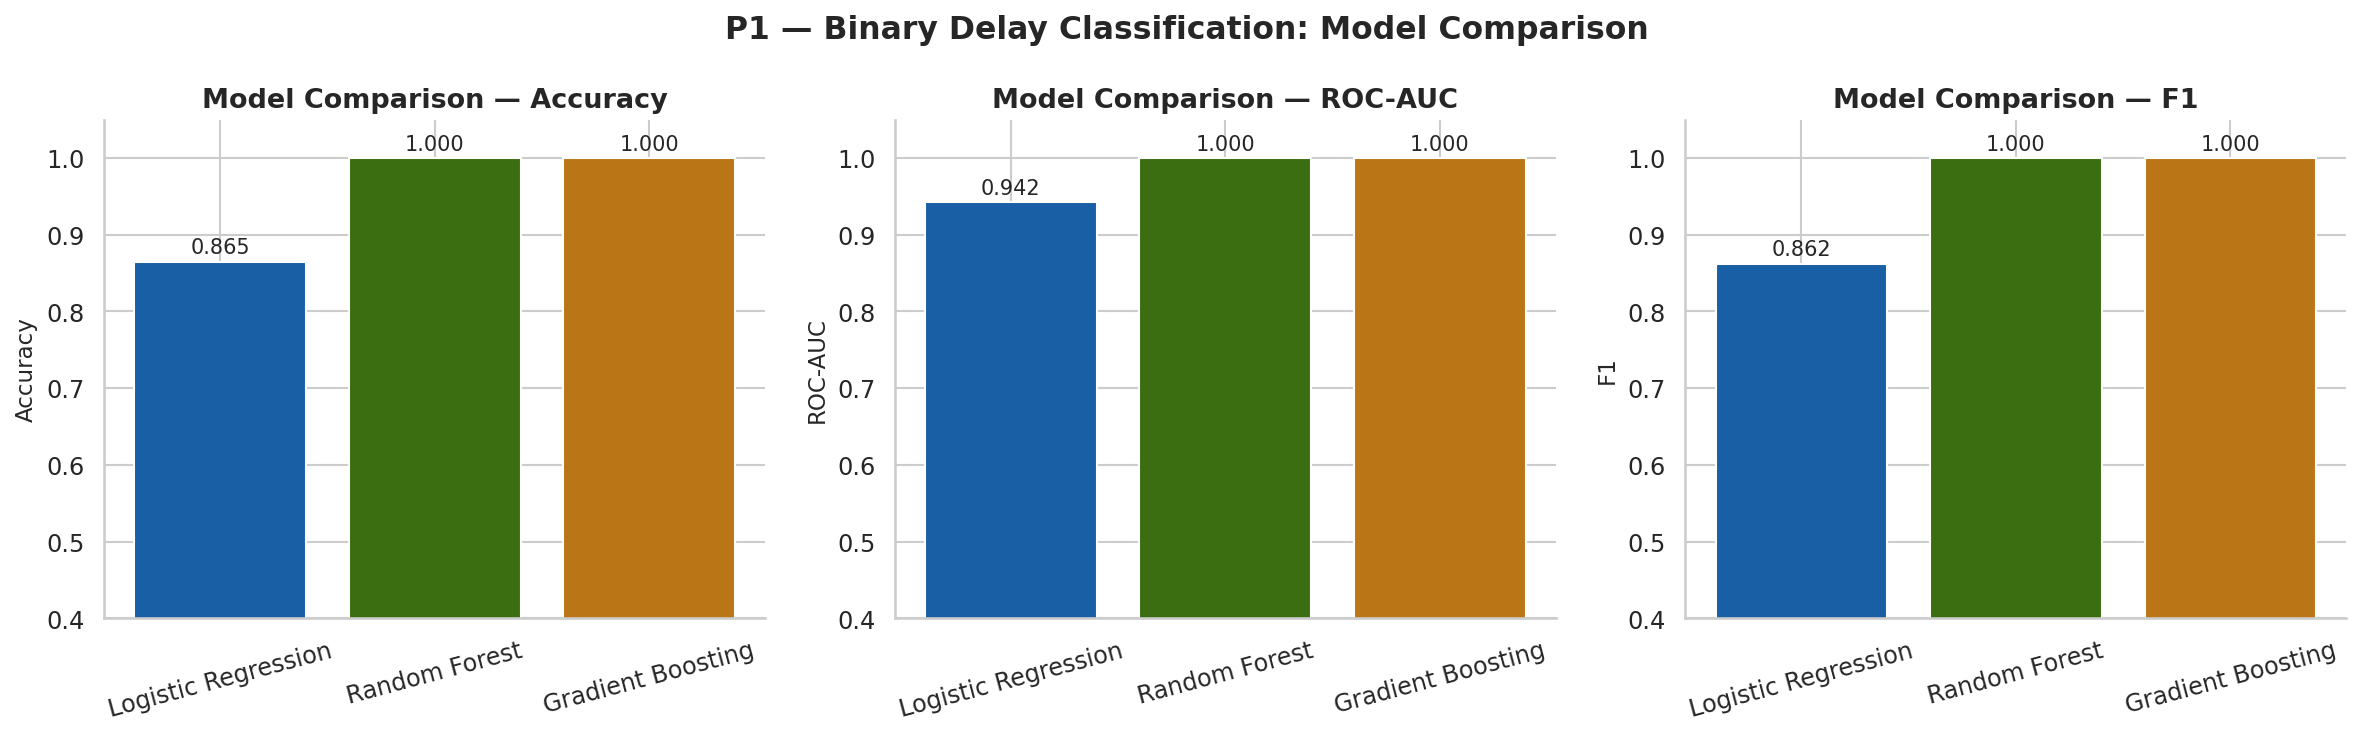

  ✓ saved  ./outputs/P1_model_comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(["Accuracy","ROC-AUC","F1"]):
    vals  = [results_p1[m][metric] for m in models]
    names = list(models.keys())
    bars  = axes[i].bar(names, vals,
                        color=[PALETTE["primary"],PALETTE["success"],PALETTE["warning"]])
    axes[i].set_ylim(0.4, 1.05)
    axes[i].set_title(f"Model Comparison — {metric}")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=15)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=10)
fig.suptitle("P1 — Binary Delay Classification: Model Comparison", fontweight="bold")
save("P1_model_comparison")

#### P1 · ROC Curves

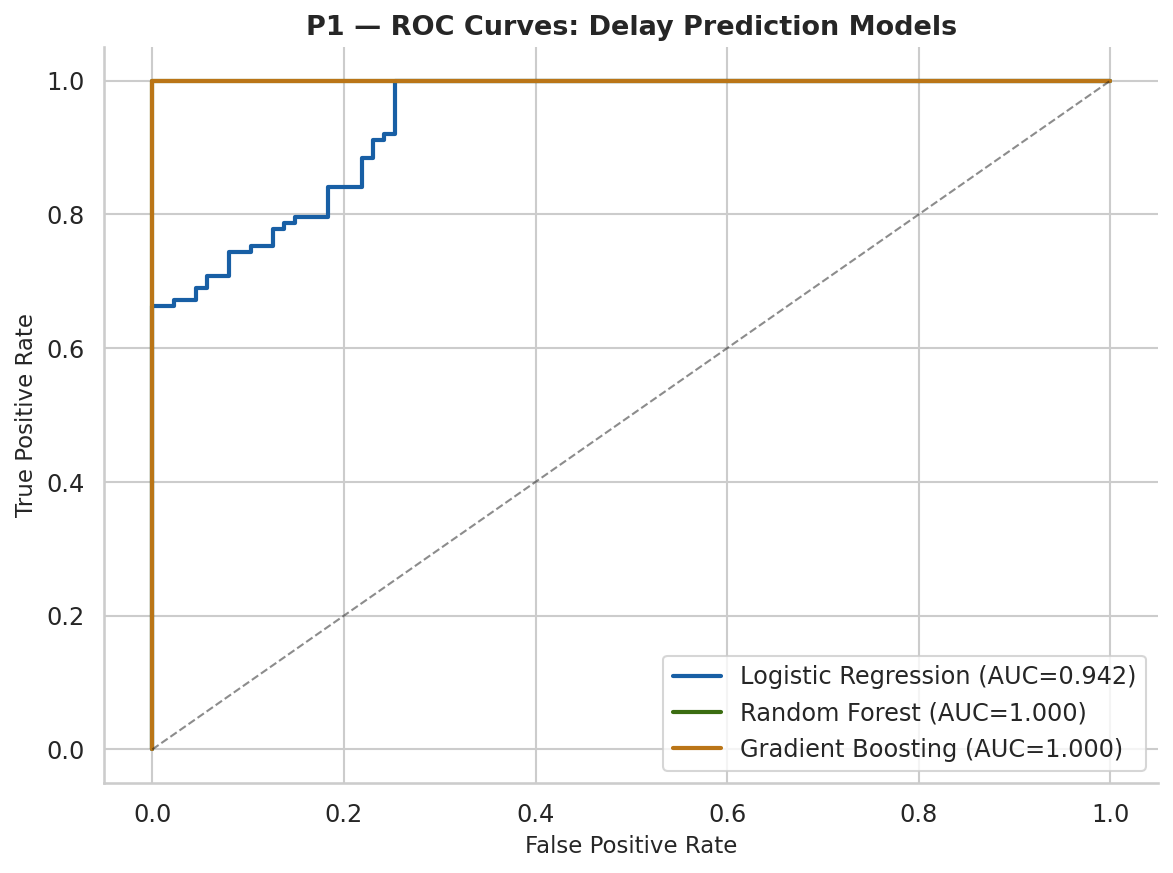

  ✓ saved  ./outputs/P1_roc_curves.png

Best model: Random Forest  AUC=1.0000
Saved → ./outputs/models/best_classifier.pkl


In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), col in zip(results_p1.items(),
                             [PALETTE["primary"], PALETTE["success"], PALETTE["warning"]]):
    fpr, tpr, _ = roc_curve(y_te, res["y_prob"])
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("P1 — ROC Curves: Delay Prediction Models")
ax.legend(loc="lower right")
save("P1_roc_curves")

best_name = max(results_p1, key=lambda x: results_p1[x]["ROC-AUC"])
print(f"\nBest model: {best_name}  AUC={results_p1[best_name]['ROC-AUC']:.4f}")
with open(f"{MDIR}/best_classifier.pkl","wb") as f:
    pickle.dump(results_p1[best_name]["model"], f)
print(f"Saved → {MDIR}/best_classifier.pkl")

### P2 · Feature Importance — Random Forest

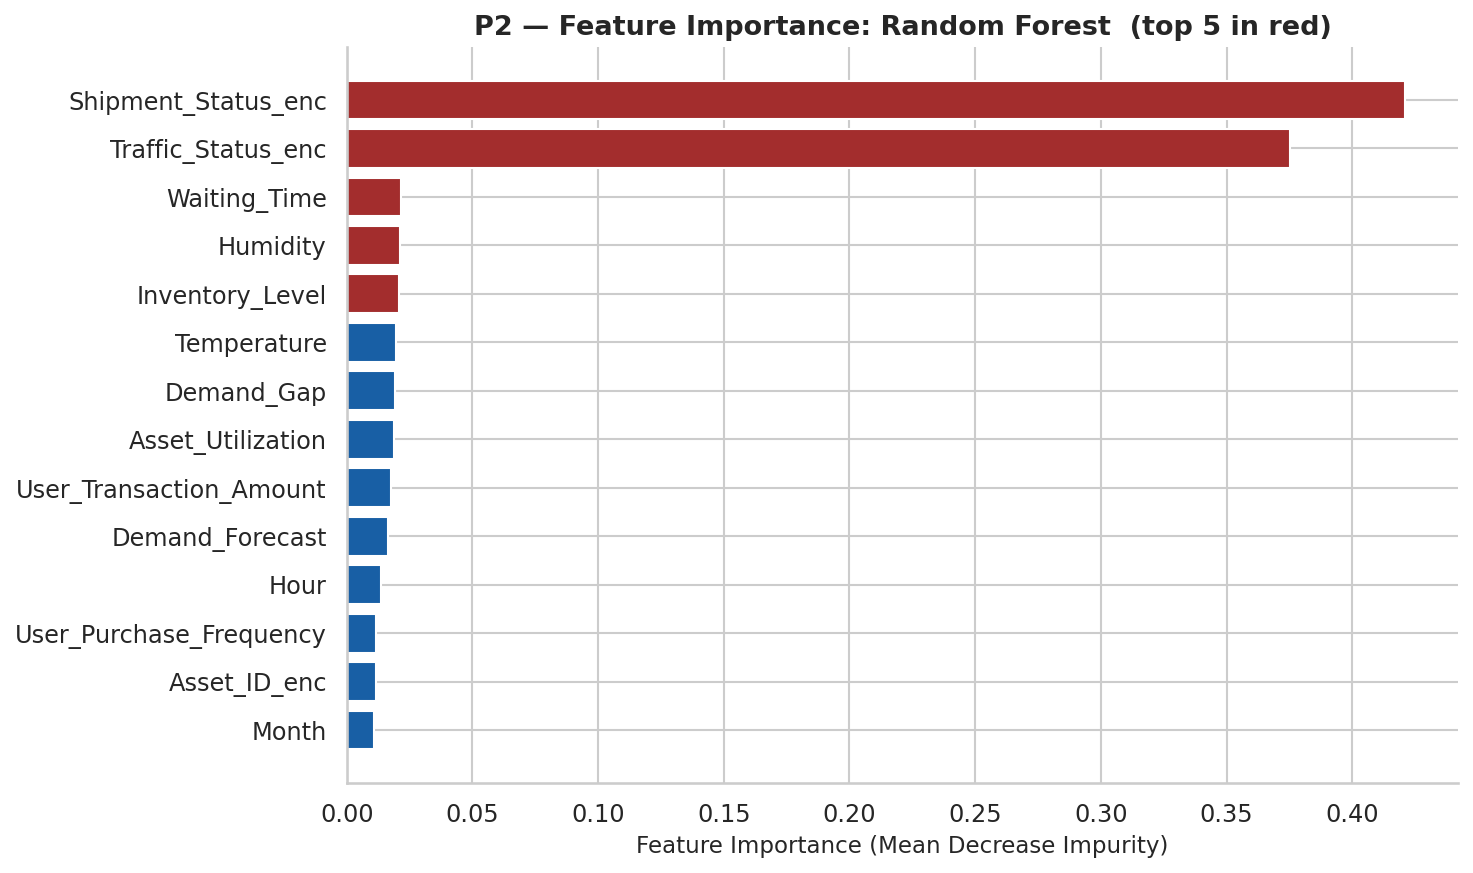

  ✓ saved  ./outputs/P2_feature_importance.png
Top 10 by permutation importance:


,Permutation Importance
Shipment_Status_enc,0.314667
Traffic_Status_enc,0.293667
Inventory_Level,0.000000
Temperature,0.000000
Humidity,0.000000
Waiting_Time,0.000000
User_Transaction_Amount,0.000000
User_Purchase_Frequency,0.000000
Asset_Utilization,0.000000
Demand_Forecast,0.000000


In [24]:
rf_model    = results_p1["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = [PALETTE["danger"] if i < 5 else PALETTE["primary"] for i in range(len(importances))]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors_imp[::-1])
ax.set_xlabel("Feature Importance (Mean Decrease Impurity)")
ax.set_title("P2 — Feature Importance: Random Forest  (top 5 in red)")
save("P2_feature_importance")

perm = permutation_importance(rf_model, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 by permutation importance:")
display(perm_imp.head(10).to_frame("Permutation Importance"))

### P3 · Operational-Only vs Operational + IoT Features

In [ ]:
ops_cols = ["Inventory_Level","Waiting_Time","User_Transaction_Amount",
            "User_Purchase_Frequency","Demand_Forecast","Demand_Gap",
            "Month","Hour","Shipment_Status_enc","Traffic_Status_enc","Asset_ID_enc"]
iot_cols = ops_cols + ["Temperature","Humidity","Asset_Utilization"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_ops = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                             df_ml[ops_cols], y, cv=cv, scoring="roc_auc")
scores_iot = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                             df_ml[iot_cols], y, cv=cv, scoring="roc_auc")
print(f"Operational only  → CV AUC: {scores_ops.mean():.4f} ± {scores_ops.std():.4f}")
print(f"+ IoT features    → CV AUC: {scores_iot.mean():.4f} ± {scores_iot.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([scores_ops, scores_iot],
           labels=["Operational Only", "Operational + IoT"],
           patch_artist=True,
           boxprops   =dict(facecolor=PALETTE["light"],  color=PALETTE["primary"]),
           medianprops=dict(color=PALETTE["danger"], linewidth=2))
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("P3 — Operational vs Operational+IoT: ROC-AUC Comparison")
ax.axhline(y=0.5, color=PALETTE["muted"], linestyle=":", linewidth=1)
save("P3_feature_comparison")

### P4 · Waiting Time Regression

  Linear Regression           RMSE=14.77  R²=-0.0146
  Random Forest Reg.          RMSE=15.09  R²=-0.0583
  Gradient Boosting R.        RMSE=15.29  R²=-0.0866


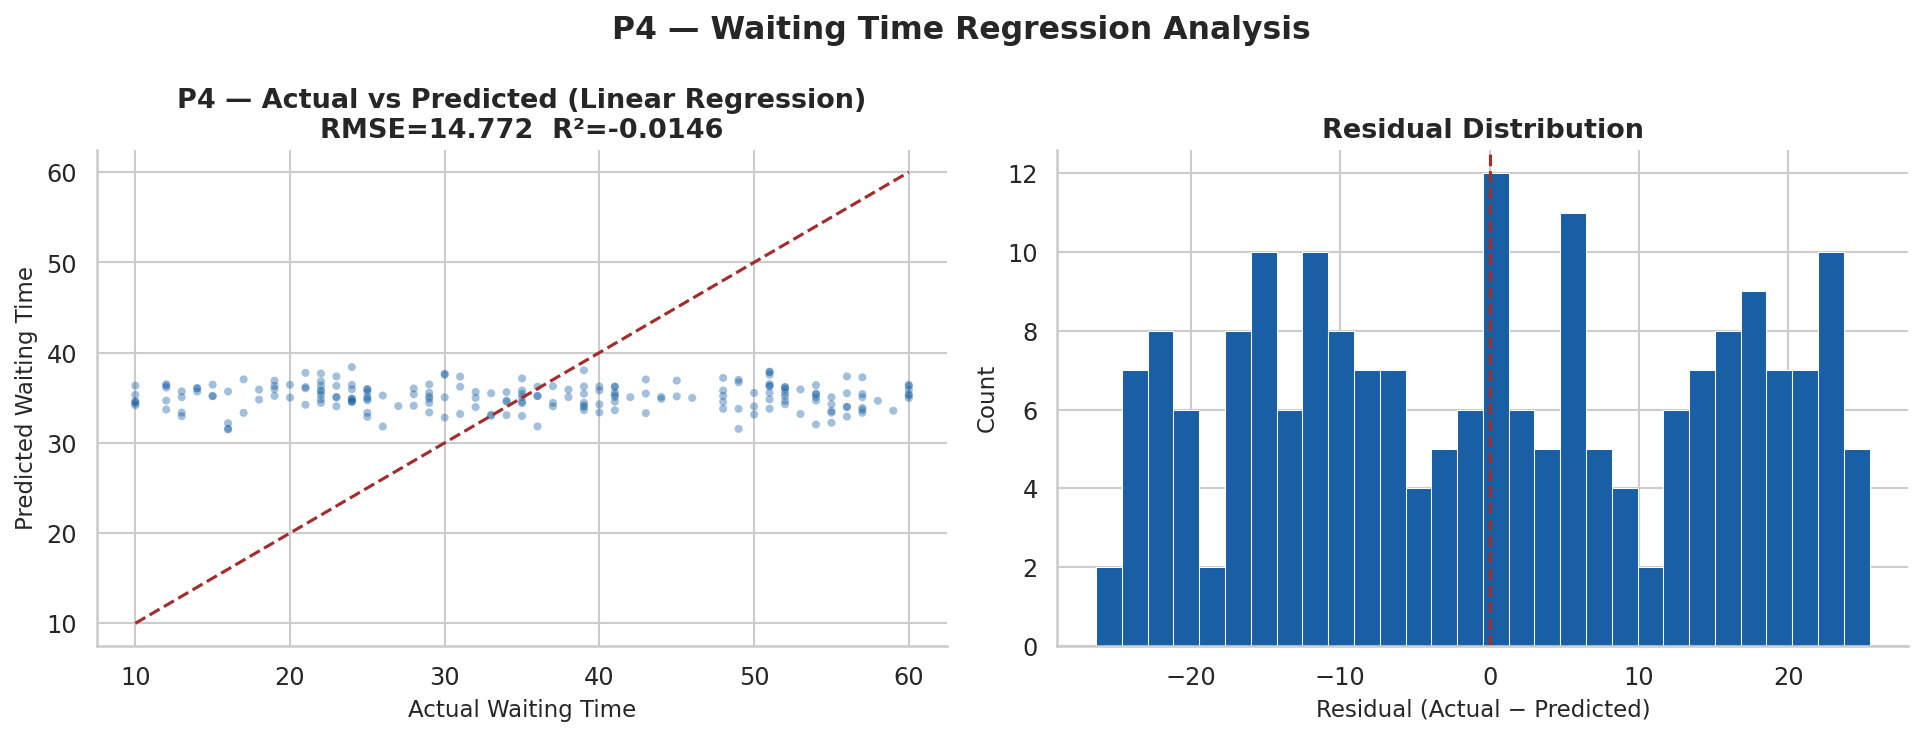

  ✓ saved  ./outputs/P4_waiting_time_regression.png


In [25]:
reg_cols = ["Temperature","Humidity","Asset_Utilization","Inventory_Level",
            "Demand_Forecast","Demand_Gap","Traffic_Status_enc","Asset_ID_enc","Month","Hour"]
Xr = df_ml[reg_cols]
yr = df_ml["Waiting_Time"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)
Xr_tr_s = scaler.fit_transform(Xr_tr)
Xr_te_s = scaler.transform(Xr_te)

reg_models = {
    "Linear Regression"   : LinearRegression(),
    "Random Forest Reg."  : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting R.": GradientBoostingRegressor(n_estimators=200, random_state=42),
}
reg_results = {}
for rname, rmodel in reg_models.items():
    if "Linear" in rname:
        rmodel.fit(Xr_tr_s, yr_tr); yr_pred = rmodel.predict(Xr_te_s)
    else:
        rmodel.fit(Xr_tr, yr_tr);   yr_pred = rmodel.predict(Xr_te)
    rmse = np.sqrt(mean_squared_error(yr_te, yr_pred))
    r2   = r2_score(yr_te, yr_pred)
    reg_results[rname] = {"RMSE": round(rmse,3), "R2": round(r2,4), "y_pred": yr_pred}
    print(f"  {rname:26s}  RMSE={rmse:.2f}  R²={r2:.4f}")

best_reg_name = min(reg_results, key=lambda x: reg_results[x]["RMSE"])
best_yr_pred  = reg_results[best_reg_name]["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(yr_te, best_yr_pred, alpha=0.4, s=15, color=PALETTE["primary"], edgecolors="none")
lims = [min(yr_te.min(), best_yr_pred.min()), max(yr_te.max(), best_yr_pred.max())]
axes[0].plot(lims, lims, color=PALETTE["danger"], linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Actual Waiting Time")
axes[0].set_ylabel("Predicted Waiting Time")
axes[0].set_title(f"P4 — Actual vs Predicted ({best_reg_name})\nRMSE={reg_results[best_reg_name]['RMSE']}  R²={reg_results[best_reg_name]['R2']}")

residuals = yr_te.values - best_yr_pred
axes[1].hist(residuals, bins=30, color=PALETTE["primary"], edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color=PALETTE["danger"], linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
fig.suptitle("P4 — Waiting Time Regression Analysis", fontweight="bold")
save("P4_waiting_time_regression")

### P5 · Demand Forecast — Time Series

In [ ]:
ts = df.groupby("Timestamp")["Demand_Forecast"].mean().resample("W").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color=PALETTE["primary"], linewidth=1.5,
        label="Weekly Avg Demand Forecast")
rolling = ts.rolling(window=4, min_periods=1).mean()
ax.plot(rolling.index, rolling.values, color=PALETTE["danger"],
        linewidth=2, linestyle="--", label="4-Week Rolling Mean")
ax.fill_between(ts.index, ts.values, rolling.values, alpha=0.15, color=PALETTE["primary"])
ax.set_xlabel("Date")
ax.set_ylabel("Demand Forecast (units)")
ax.set_title("P5 — Demand Forecast Time Series  (weekly + 4-week rolling mean)")
ax.legend()
save("P5_demand_time_series")

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_demand = df.groupby("MonthName")["Demand_Forecast"].mean().reindex(month_order).dropna()
print("Monthly avg demand forecast:")
display(monthly_demand.round(1).to_frame("Avg Demand Forecast"))

### P6 · Shipment Risk Clustering — K-Means

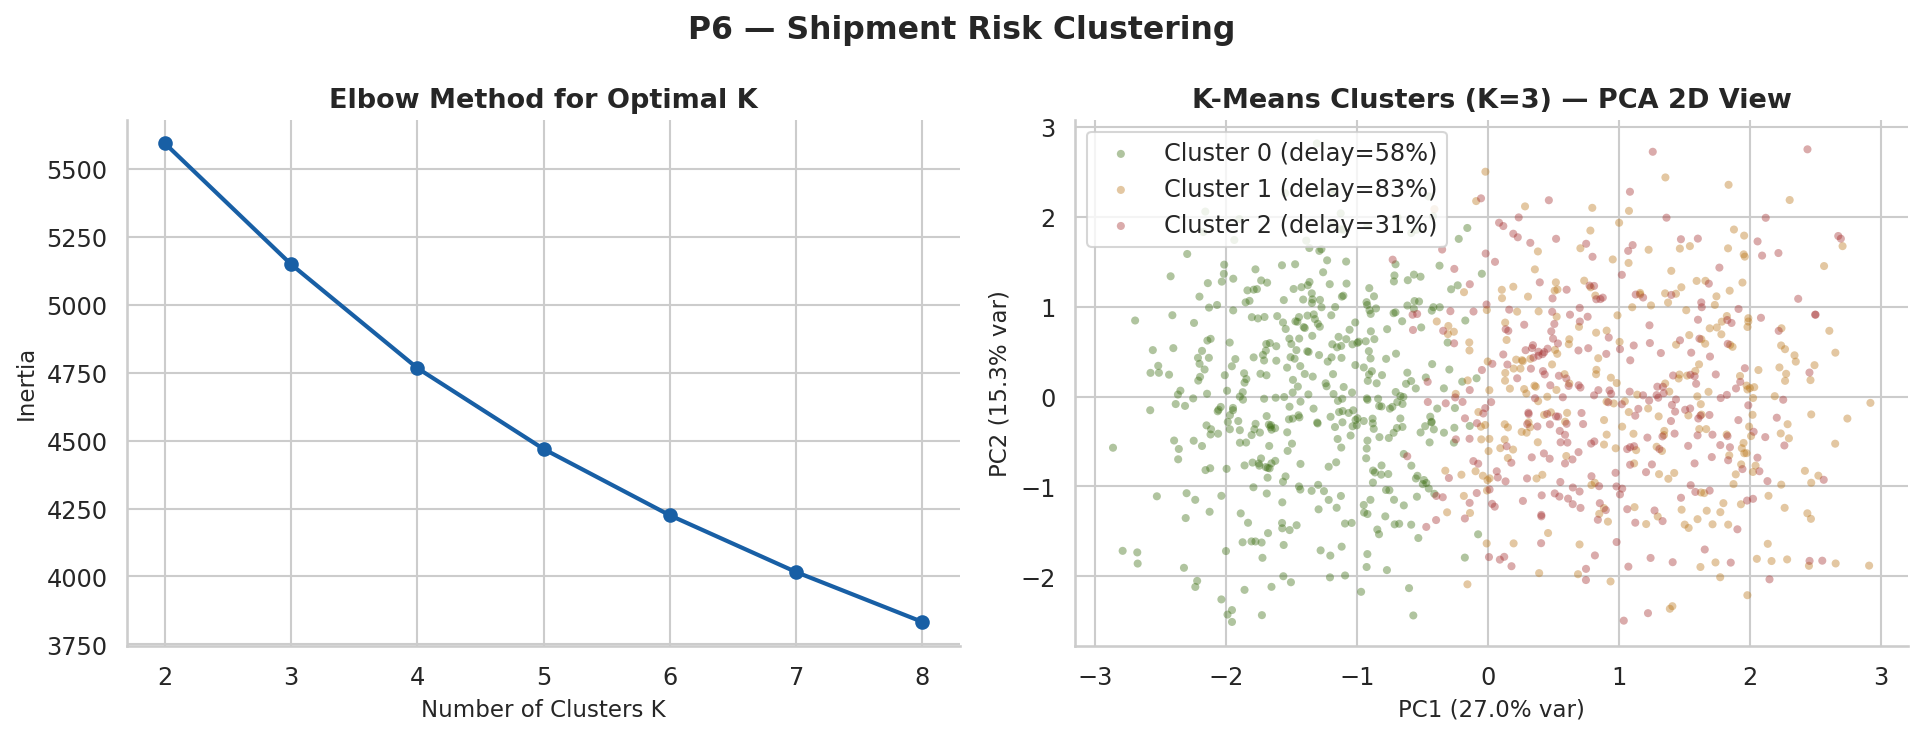

  ✓ saved  ./outputs/P6_risk_clustering.png

Cluster Profiles:


,Delay_Rate,Avg_Wait,Avg_Temp,Avg_Util,Count
Cluster,,,,,
0,0.580000,35.480000,23.910000,78.840000,433
1,0.830000,29.640000,23.860000,80.270000,276
2,0.310000,39.580000,23.900000,80.090000,291


In [26]:
cluster_cols = ["Temperature","Humidity","Waiting_Time","Asset_Utilization",
                "Inventory_Level","Demand_Gap","Traffic_Status_enc"]
Xc = df_ml[cluster_cols]
scaler_c = StandardScaler()
Xc_s = scaler_c.fit_transform(Xc)

inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xc_s)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(2, 9), inertias, "o-", color=PALETTE["primary"], linewidth=2)
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method for Optimal K")

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml["Cluster"] = km3.fit_predict(Xc_s)

pca2  = PCA(n_components=2, random_state=42)
Xc_pca = pca2.fit_transform(Xc_s)
cluster_palette = {0: PALETTE["success"], 1: PALETTE["warning"], 2: PALETTE["danger"]}
for cl in [0, 1, 2]:
    mask = df_ml["Cluster"] == cl
    dr   = df_ml[mask]["Logistics_Delay"].mean() * 100
    axes[1].scatter(Xc_pca[mask, 0], Xc_pca[mask, 1],
                    c=cluster_palette[cl], alpha=0.4, s=15, edgecolors="none",
                    label=f"Cluster {cl} (delay={dr:.0f}%)")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].set_title("K-Means Clusters (K=3) — PCA 2D View")
axes[1].legend()
fig.suptitle("P6 — Shipment Risk Clustering", fontweight="bold")
save("P6_risk_clustering")

cluster_profile = df_ml.groupby("Cluster").agg(
    Delay_Rate=("Logistics_Delay","mean"), Avg_Wait=("Waiting_Time","mean"),
    Avg_Temp  =("Temperature","mean"),    Avg_Util=("Asset_Utilization","mean"),
    Count     =("Logistics_Delay","count")).round(2)
print("\nCluster Profiles:")
display(cluster_profile.style.background_gradient(cmap="RdYlGn_r", subset=["Delay_Rate"]))

### P7 · Anomaly Detection — Isolation Forest

Anomalies detected: 50 (5.0%)
Delay rate — anomalies : 54.0%
Delay rate — normal    : 56.7%


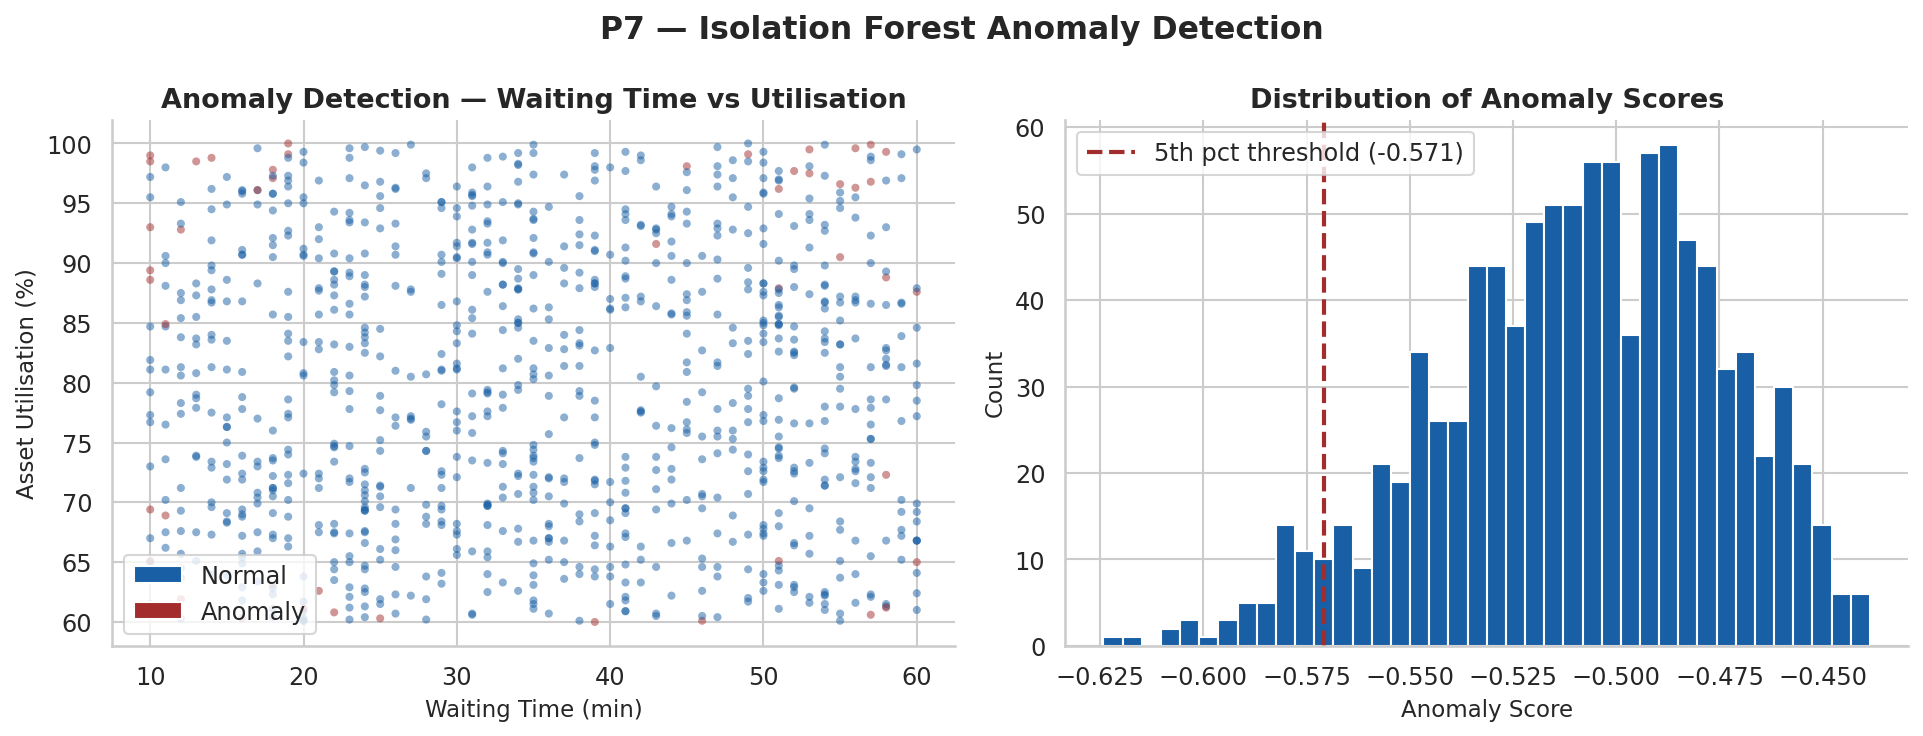

  ✓ saved  ./outputs/P7_anomaly_detection.png
Saved → ./outputs/models/isolation_forest.pkl


In [27]:
anomaly_cols = ["Waiting_Time","Temperature","Humidity","Asset_Utilization","Inventory_Level"]
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
df_ml["Anomaly_Score"]  = iso.fit_predict(df_ml[anomaly_cols])
df_ml["Anomaly_ScoreF"] = iso.score_samples(df_ml[anomaly_cols])

n_anom = (df_ml["Anomaly_Score"] == -1).sum()
print(f"Anomalies detected: {n_anom} ({n_anom/len(df_ml)*100:.1f}%)")
print(f"Delay rate — anomalies : {df_ml[df_ml['Anomaly_Score']==-1]['Logistics_Delay'].mean()*100:.1f}%")
print(f"Delay rate — normal    : {df_ml[df_ml['Anomaly_Score']==1]['Logistics_Delay'].mean()*100:.1f}%")

from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df_ml["Waiting_Time"], df_ml["Asset_Utilization"],
                c=df_ml["Anomaly_Score"].map({1: PALETTE["primary"], -1: PALETTE["danger"]}),
                alpha=0.5, s=15, edgecolors="none")
axes[0].set_xlabel("Waiting Time (min)")
axes[0].set_ylabel("Asset Utilisation (%)")
axes[0].set_title("Anomaly Detection — Waiting Time vs Utilisation")
axes[0].legend(handles=[Patch(facecolor=PALETTE["primary"], label="Normal"),
                         Patch(facecolor=PALETTE["danger"],  label="Anomaly")])

threshold = np.percentile(df_ml["Anomaly_ScoreF"], 5)
axes[1].hist(df_ml["Anomaly_ScoreF"], bins=40, color=PALETTE["primary"], edgecolor="white")
axes[1].axvline(threshold, color=PALETTE["danger"], linewidth=2, linestyle="--",
                label=f"5th pct threshold ({threshold:.3f})")
axes[1].set_xlabel("Anomaly Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Anomaly Scores")
axes[1].legend()
fig.suptitle("P7 — Isolation Forest Anomaly Detection", fontweight="bold")
save("P7_anomaly_detection")
with open(f"{MDIR}/isolation_forest.pkl","wb") as f: pickle.dump(iso, f)
print(f"Saved → {MDIR}/isolation_forest.pkl")

### P8 · Root Cause Classification — Delay Reason

Classes: ['Mechanical Failure', 'None', 'Traffic', 'Weather']
Delayed records with known reason: 566

Decision Tree — Accuracy: 0.254
                    precision    recall  f1-score   support

Mechanical Failure       0.29      0.19      0.23        27
              None       0.12      0.10      0.11        30
           Traffic       0.27      0.48      0.35        27
           Weather       0.32      0.27      0.29        30

          accuracy                           0.25       114
         macro avg       0.25      0.26      0.24       114
      weighted avg       0.25      0.25      0.24       114


Random Forest — Accuracy: 0.228
                    precision    recall  f1-score   support

Mechanical Failure       0.20      0.15      0.17        27
              None       0.19      0.23      0.21        30
           Traffic       0.19      0.19      0.19        27
           Weather       0.33      0.33      0.33        30

          accuracy                           0.2

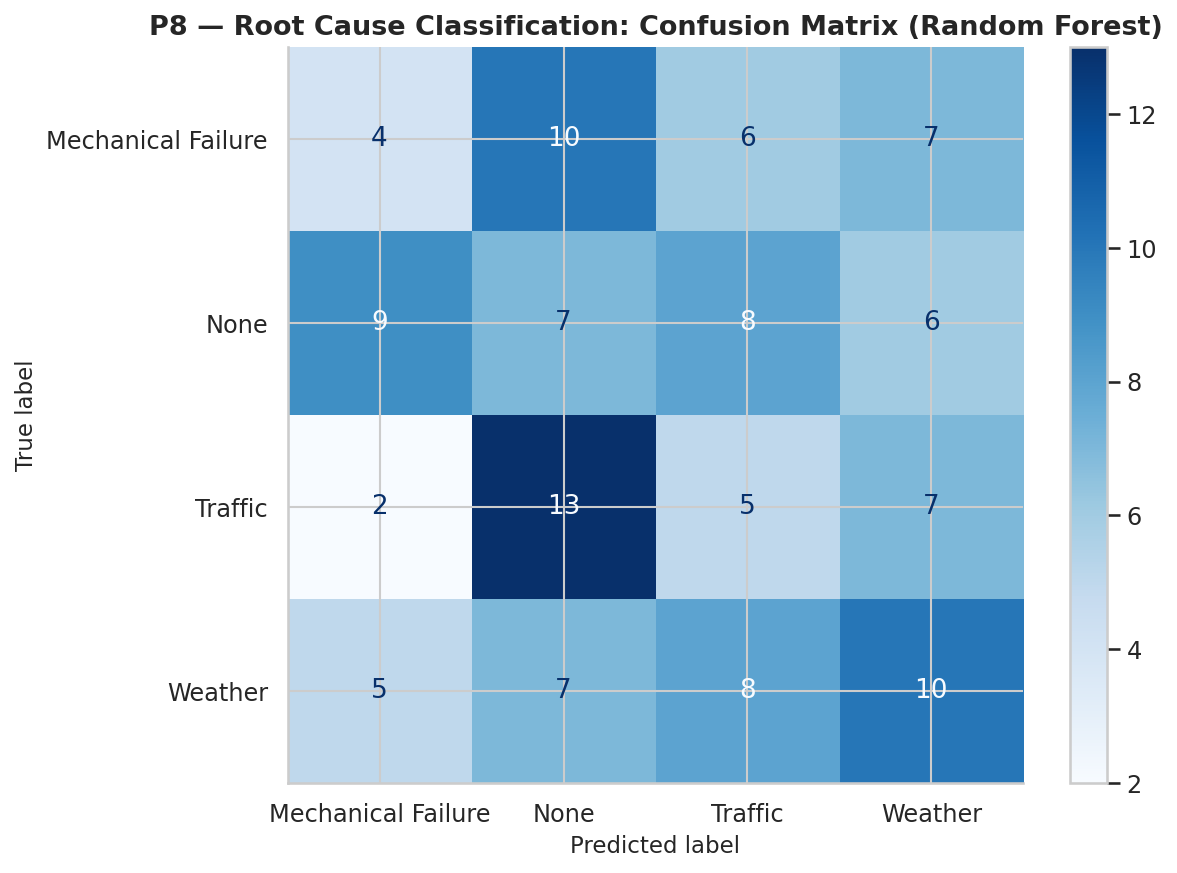

  ✓ saved  ./outputs/P8_root_cause_confusion_matrix.png


In [28]:
delayed_ml = df_ml[df_ml["Logistics_Delay"]==1].dropna(subset=["Logistics_Delay_Reason"]).copy()
le_reason  = LabelEncoder()
delayed_ml["Reason_enc"] = le_reason.fit_transform(delayed_ml["Logistics_Delay_Reason"])
reason_classes = le_reason.classes_
print(f"Classes: {reason_classes.tolist()}")
print(f"Delayed records with known reason: {len(delayed_ml):,}")

rc_cols = ["Temperature","Humidity","Asset_Utilization","Inventory_Level",
           "Waiting_Time","Traffic_Status_enc","Demand_Gap","Month","Hour"]
Xrc = delayed_ml[rc_cols];  yrc = delayed_ml["Reason_enc"]
Xrc_tr, Xrc_te, yrc_tr, yrc_te = train_test_split(Xrc, yrc, test_size=0.2,
                                                    random_state=42, stratify=yrc)
rc_models = {"Decision Tree" : DecisionTreeClassifier(max_depth=6, random_state=42),
             "Random Forest" : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)}

for rname, rmodel in rc_models.items():
    rmodel.fit(Xrc_tr, yrc_tr)
    pred = rmodel.predict(Xrc_te)
    print(f"\n{rname} — Accuracy: {accuracy_score(yrc_te, pred):.3f}")
    print(classification_report(yrc_te, pred, target_names=reason_classes))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(yrc_te, rc_models["Random Forest"].predict(Xrc_te)),
                       display_labels=reason_classes).plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("P8 — Root Cause Classification: Confusion Matrix (Random Forest)")
save("P8_root_cause_confusion_matrix")
with open(f"{MDIR}/root_cause_classifier.pkl","wb") as f: pickle.dump(rc_models["Random Forest"], f)

### P9 · Demand Gap as Standalone Predictor

Point-biserial correlation & significance vs Logistics_Delay:
  Demand_Gap                 r=-0.0057  p=0.8572  ✗ not significant
  Demand_Forecast            r=-0.0186  p=0.5564  ✗ not significant
  Inventory_Level            r=-0.0033  p=0.9160  ✗ not significant


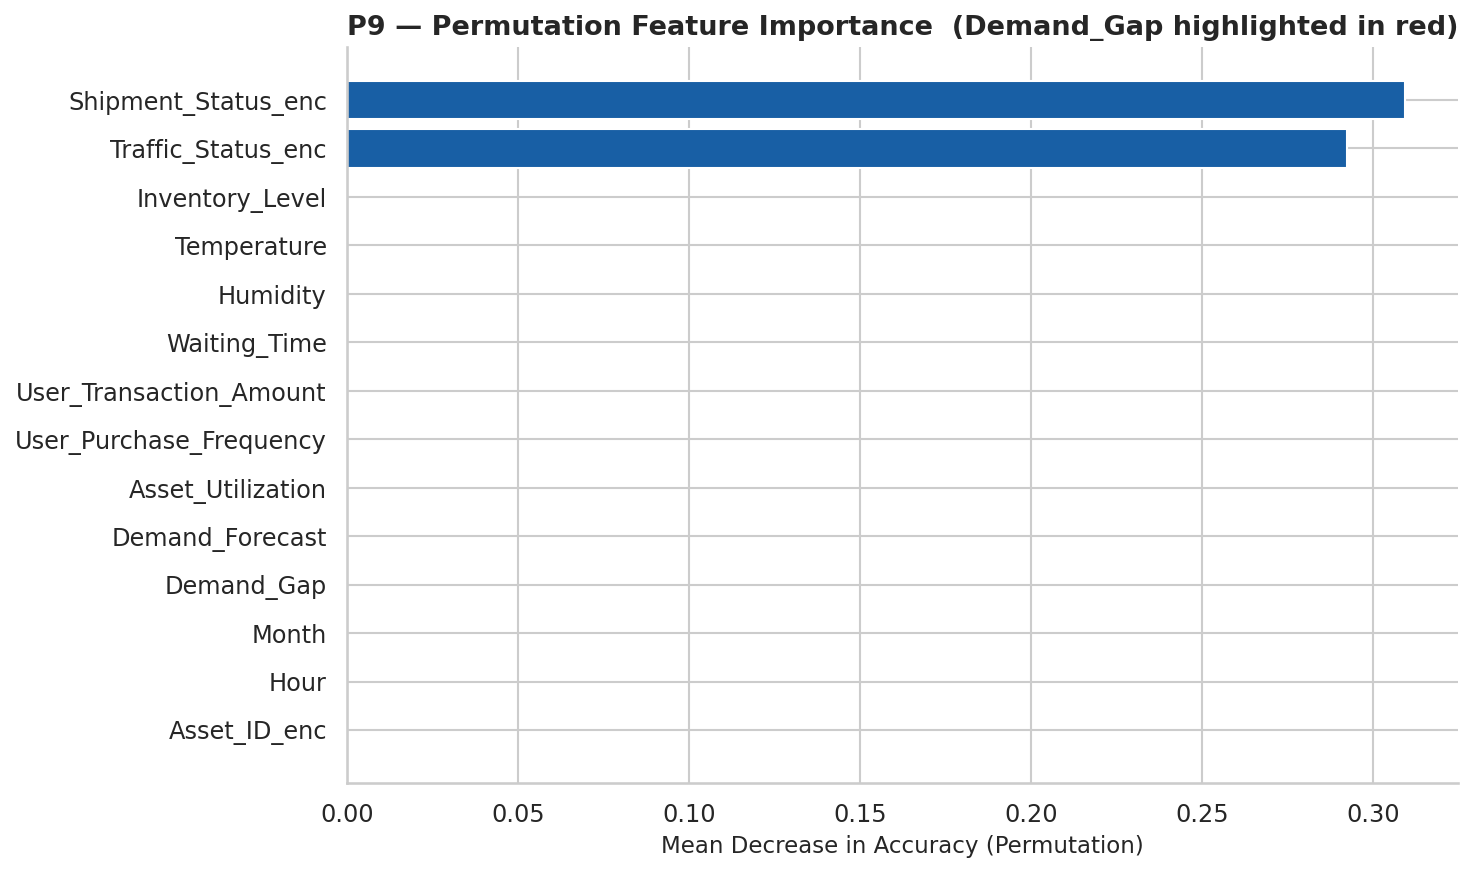

  ✓ saved  ./outputs/P9_permutation_importance.png


In [29]:
print("Point-biserial correlation & significance vs Logistics_Delay:")
for col in ["Demand_Gap","Demand_Forecast","Inventory_Level"]:
    t_stat, p_val = stats.pointbiserialr(df["Logistics_Delay"], df[col])
    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"  {col:25s}  r={t_stat:+.4f}  p={p_val:.4f}  {sig}")

rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_full.fit(X_tr, y_tr)
perm_full = permutation_importance(rf_full, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
perm_series = pd.Series(perm_full.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_perm = [PALETTE["danger"] if "Demand_Gap" in col else PALETTE["primary"]
               for col in perm_series.index[::-1]]
ax.barh(perm_series.index[::-1], perm_series.values[::-1], color=colors_perm)
ax.set_xlabel("Mean Decrease in Accuracy (Permutation)")
ax.set_title("P9 — Permutation Feature Importance  (Demand_Gap highlighted in red)")
save("P9_permutation_importance")

### P10 · Real-Time Pre-Departure Scoring Model

  Logistic Regression       Acc=0.675  AUC=0.792  F1=0.667
  Random Forest             Acc=0.755  AUC=0.791  F1=0.754
  Gradient Boosting         Acc=0.730  AUC=0.772  F1=0.730


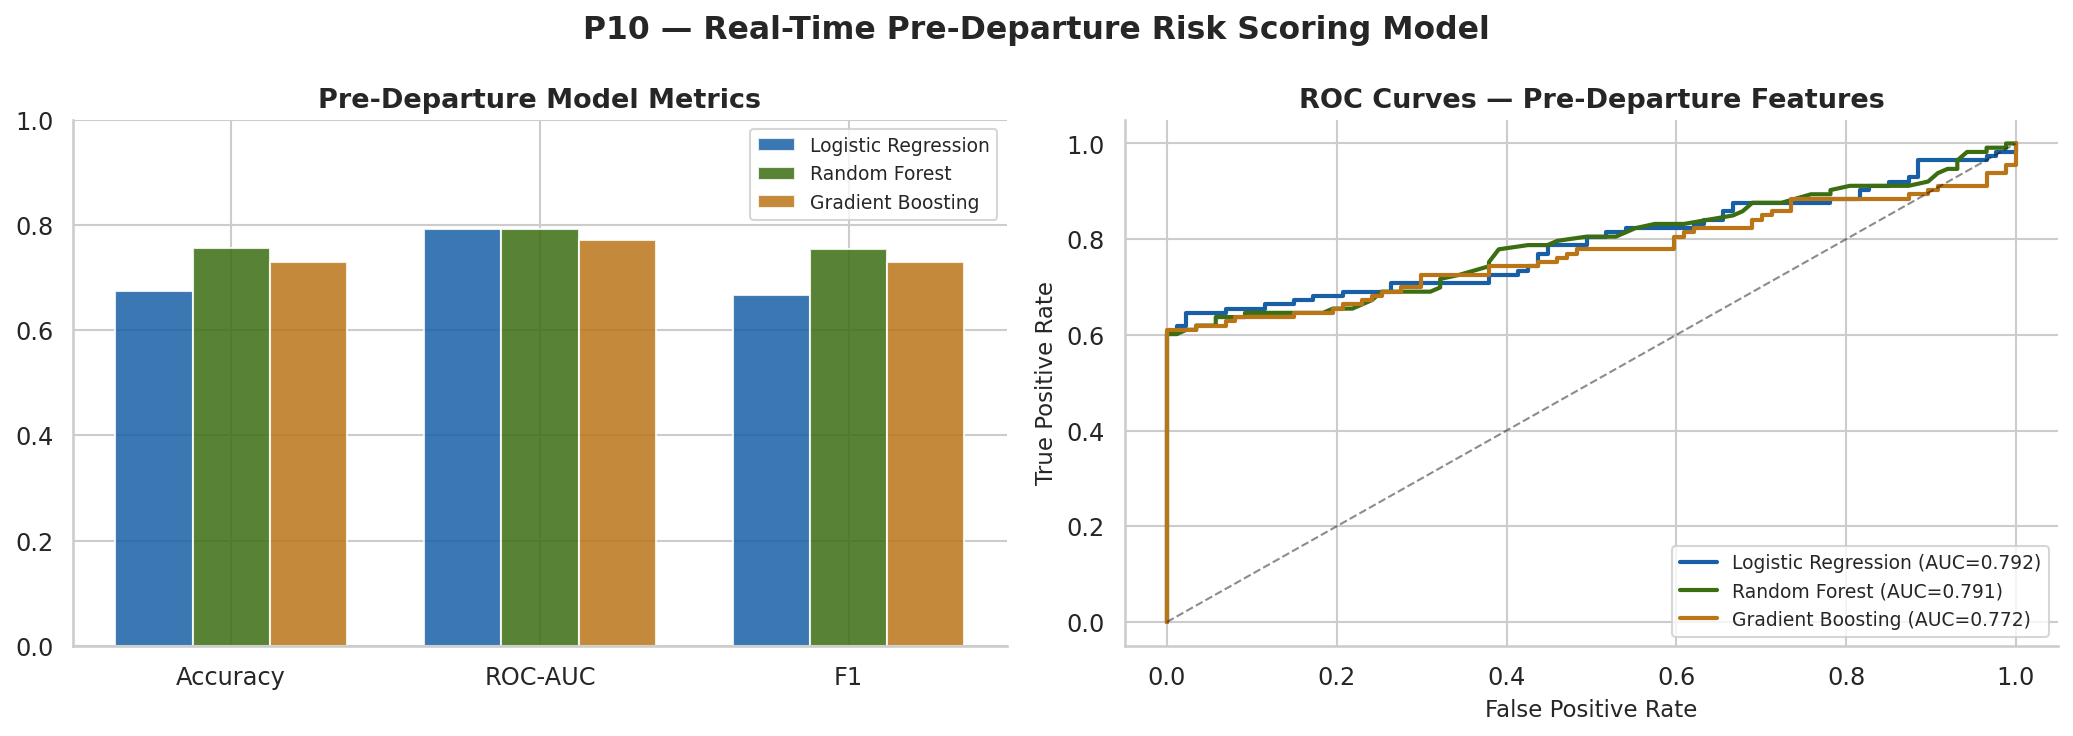

  ✓ saved  ./outputs/P10_predeparture_scoring.png

Best pre-departure model: Logistic Regression  →  saved


In [30]:
pre_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}
pre_results = {}
for pname, pmodel in pre_models.items():
    if "Logistic" in pname:
        pmodel.fit(Xp_tr_s, yp_tr); yp_pred = pmodel.predict(Xp_te_s); yp_prob = pmodel.predict_proba(Xp_te_s)[:,1]
    else:
        pmodel.fit(Xp_tr, yp_tr);   yp_pred = pmodel.predict(Xp_te);   yp_prob = pmodel.predict_proba(Xp_te)[:,1]
    acc = accuracy_score(yp_te, yp_pred)
    auc = roc_auc_score(yp_te, yp_prob)
    f1  = float(classification_report(yp_te, yp_pred, output_dict=True)["weighted avg"]["f1-score"])
    pre_results[pname] = {"Accuracy": acc, "ROC-AUC": auc, "F1": f1,
                          "model": pmodel, "y_prob": yp_prob}
    print(f"  {pname:24s}  Acc={acc:.3f}  AUC={auc:.3f}  F1={f1:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x     = np.arange(3)
width = 0.25
colors_pre = [PALETTE["primary"], PALETTE["success"], PALETTE["warning"]]
for i, (mname, vals) in enumerate(pre_results.items()):
    mv = [vals["Accuracy"], vals["ROC-AUC"], vals["F1"]]
    axes[0].bar(x + i*width, mv, width, label=mname, color=colors_pre[i], alpha=0.85)
axes[0].set_xticks(x + width);  axes[0].set_xticklabels(["Accuracy","ROC-AUC","F1"])
axes[0].set_ylim(0, 1);         axes[0].set_title("Pre-Departure Model Metrics")
axes[0].legend(fontsize=9)

for (pname, res), col in zip(pre_results.items(), colors_pre):
    fpr, tpr, _ = roc_curve(yp_te, res["y_prob"])
    axes[1].plot(fpr, tpr, color=col, linewidth=2, label=f"{pname} (AUC={res['ROC-AUC']:.3f})")
axes[1].plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5)
axes[1].set_xlabel("False Positive Rate");  axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — Pre-Departure Features")
axes[1].legend(loc="lower right", fontsize=9)
fig.suptitle("P10 — Real-Time Pre-Departure Risk Scoring Model", fontweight="bold")
save("P10_predeparture_scoring")

best_pre_name = max(pre_results, key=lambda x: pre_results[x]["ROC-AUC"])
with open(f"{MDIR}/predeparture_model.pkl","wb") as f: pickle.dump(pre_results[best_pre_name]["model"], f)
print(f"\nBest pre-departure model: {best_pre_name}  →  saved")

### P10 · Real-Time Scoring Function (Demo)

In [31]:
def score_shipment(record: dict, model, feature_cols: list) -> dict:
    """
    Score a single shipment for delay risk before departure.

    Parameters
    ----------
    record       : dict of feature values (pre-departure features)
    model        : trained classifier with .predict_proba()
    feature_cols : ordered list of feature names the model expects

    Returns
    -------
    dict with delay_probability, risk_label, recommendation
    """
    row        = pd.DataFrame([record])[feature_cols]
    prob_delay = model.predict_proba(row)[0][1]
    if prob_delay > 0.65:
        label, rec = "🔴 HIGH RISK",   "Prioritise route check & assign backup asset"
    elif prob_delay > 0.40:
        label, rec = "🟡 MEDIUM RISK", "Monitor closely during transit"
    else:
        label, rec = "🟢 LOW RISK",    "Proceed — standard monitoring"
    return {"delay_probability": round(float(prob_delay), 4),
            "risk_label"       : label,
            "recommendation"   : rec}

# Load saved model and run example
with open(f"{MDIR}/predeparture_model.pkl","rb") as f:
    rt_model = pickle.load(f)

example = {
    "Inventory_Level"        : 200,
    "Temperature"            : 35.0,
    "Humidity"               : 80.0,
    "User_Transaction_Amount": 400,
    "User_Purchase_Frequency": 8,
    "Asset_Utilization"      : 90.5,
    "Demand_Forecast"        : 280,
    "Demand_Gap"             : 80,
    "Month"                  : 8,
    "Hour"                   : 14,
    "Traffic_Status_enc"     : 1,
    "Asset_ID_enc"           : 3,
}
result = score_shipment(example, rt_model, PRE_DEPART_COLS)
print("\n📦 Example Shipment Scoring:")
for k, v in result.items():
    print(f"   {k:<25s}: {v}")


📦 Example Shipment Scoring:
   delay_probability        : 0.014
   risk_label               : 🟢 LOW RISK
   recommendation           : Proceed — standard monitoring


---
## Summary Dashboard

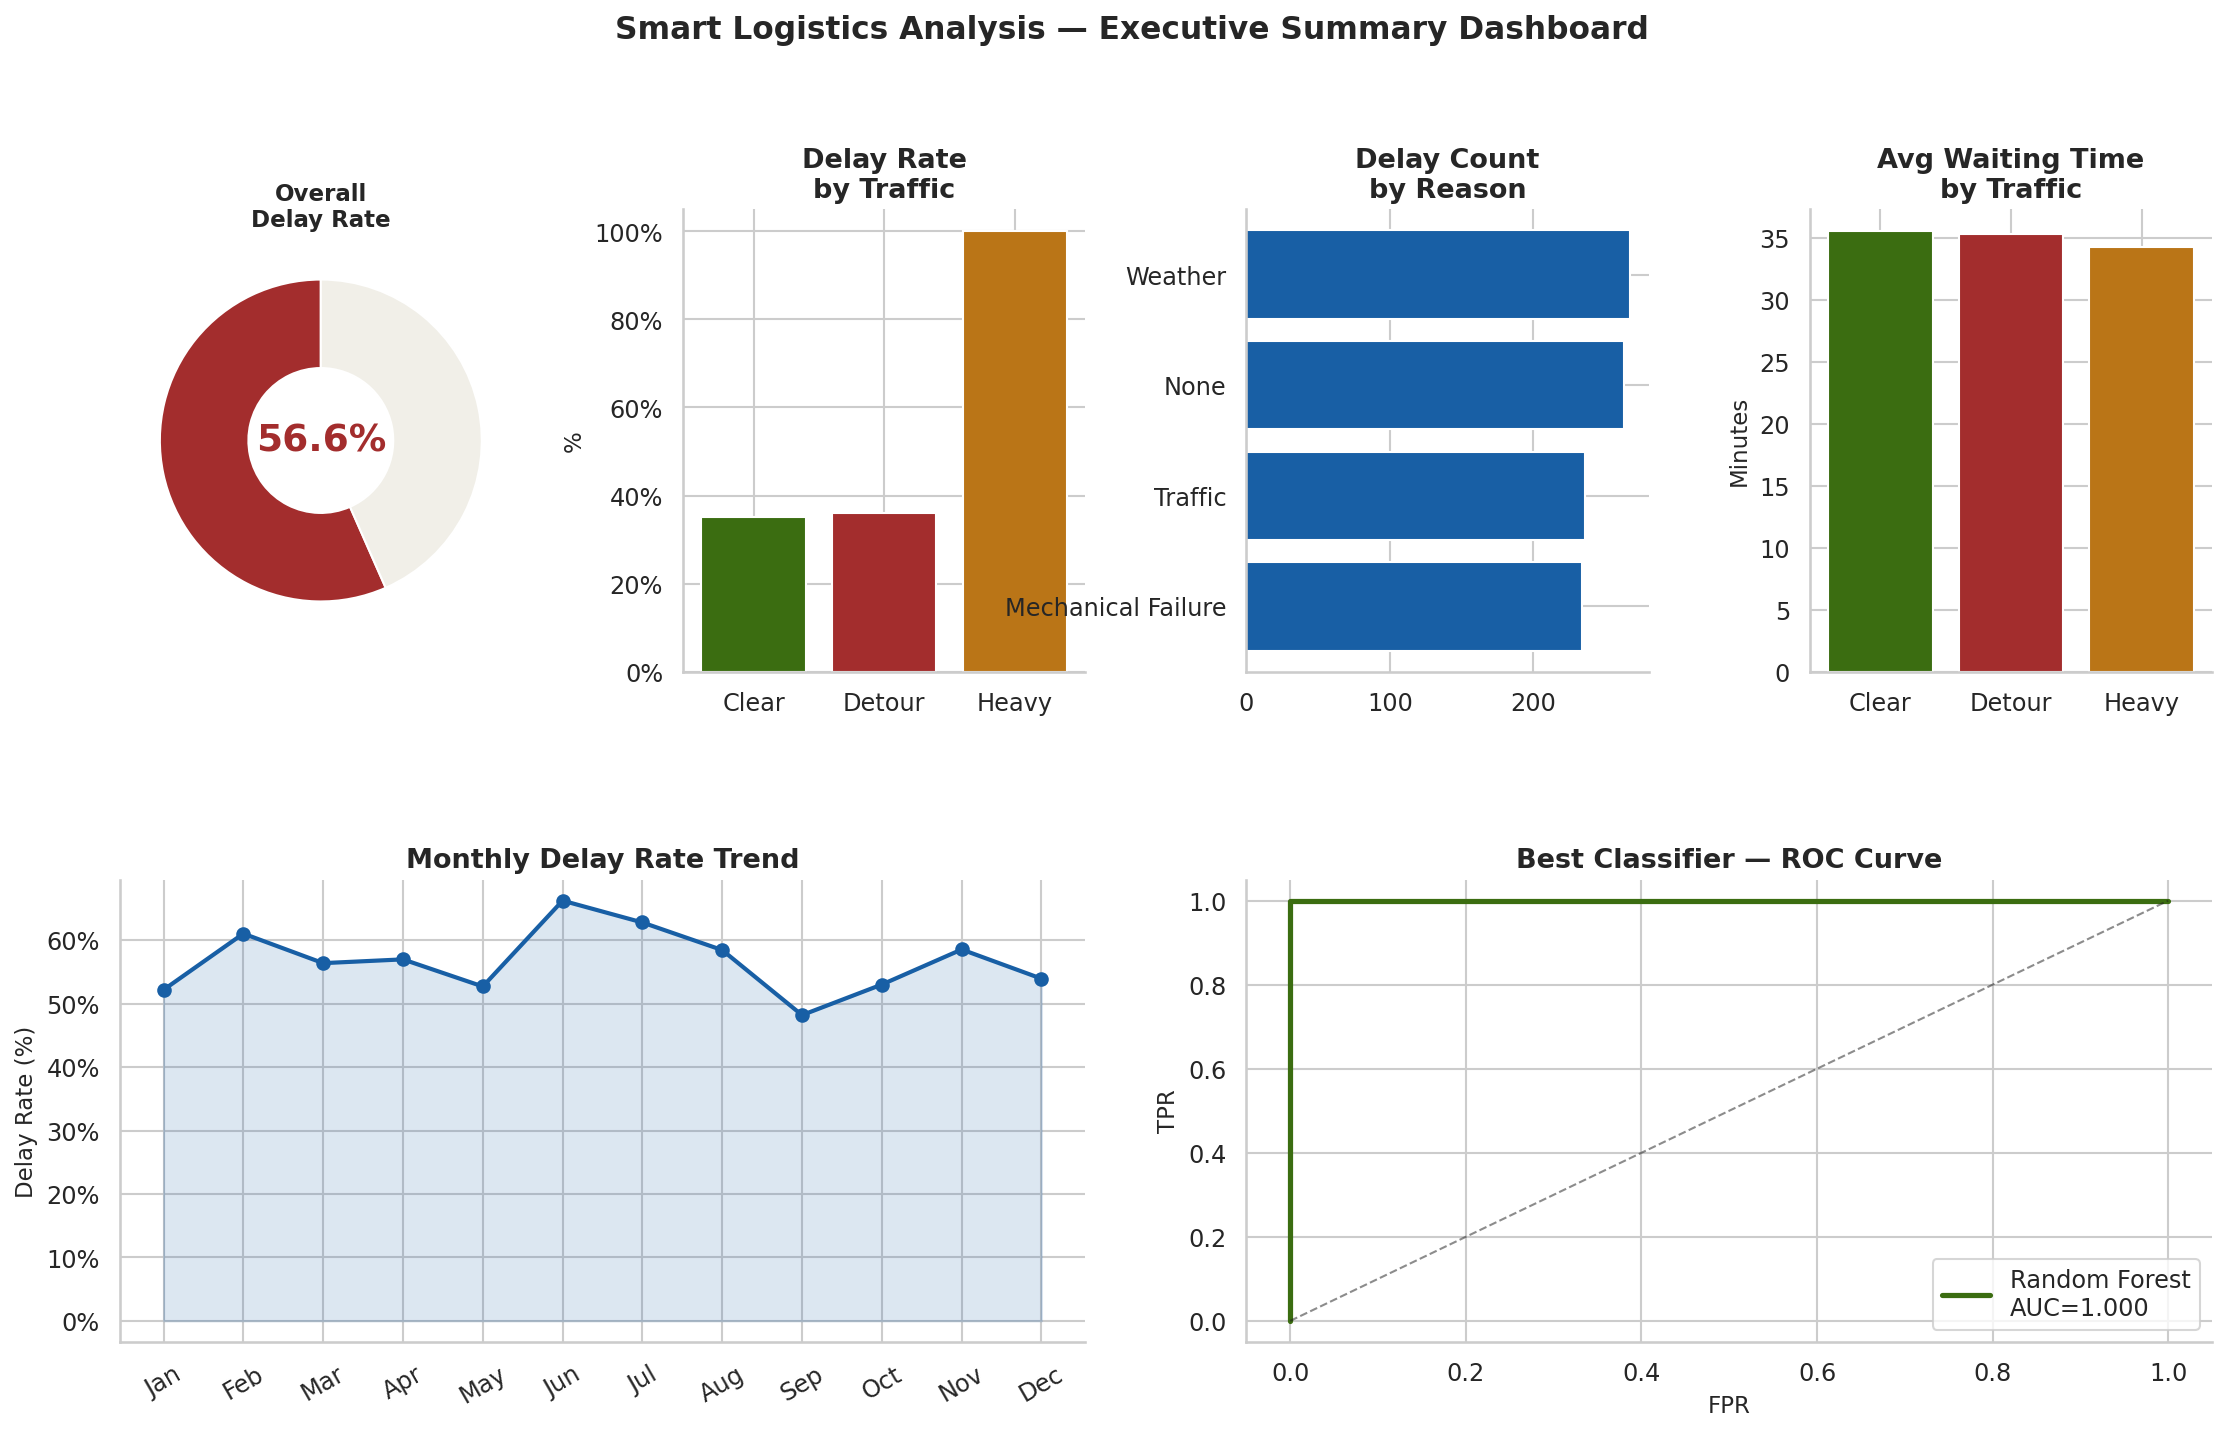

  ✓ saved  ./outputs/SUMMARY_dashboard.png

✅ All analysis complete!


In [32]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# Delay rate donut
ax1 = fig.add_subplot(gs[0, 0])
dr  = df["Logistics_Delay"].mean() * 100
ax1.pie([dr, 100-dr], colors=[PALETTE["danger"], PALETTE["light"]],
        startangle=90, wedgeprops={"width":0.55,"edgecolor":"white"})
ax1.text(0, 0, f"{dr:.1f}%", ha="center", va="center",
         fontsize=18, fontweight="bold", color=PALETTE["danger"])
ax1.set_title("Overall\nDelay Rate", fontsize=11)

# Delay by traffic
ax2 = fig.add_subplot(gs[0, 1])
td  = df.groupby("Traffic_Status")["Logistics_Delay"].mean() * 100
ax2.bar(td.index, td.values, color=[PALETTE["success"],PALETTE["danger"],PALETTE["warning"]])
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.set_title("Delay Rate\nby Traffic")
ax2.set_ylabel("%")

# Top delay reasons
ax3 = fig.add_subplot(gs[0, 2])
rd  = df.dropna(subset=["Logistics_Delay_Reason"])
rd  = rd.groupby("Logistics_Delay_Reason")["Logistics_Delay"].count().sort_values()
ax3.barh(rd.index, rd.values, color=PALETTE["primary"])
ax3.set_title("Delay Count\nby Reason")

# Avg waiting by traffic
ax4 = fig.add_subplot(gs[0, 3])
wt  = df.groupby("Traffic_Status")["Waiting_Time"].mean()
ax4.bar(wt.index, wt.values, color=[PALETTE["success"],PALETTE["danger"],PALETTE["warning"]])
ax4.set_ylabel("Minutes")
ax4.set_title("Avg Waiting Time\nby Traffic")

# Monthly trend
ax5 = fig.add_subplot(gs[1, 0:2])
md  = df.groupby("MonthName")["Logistics_Delay"].mean().reindex(month_order).dropna() * 100
ax5.plot(md.index, md.values, color=PALETTE["primary"], marker="o", linewidth=2)
ax5.fill_between(md.index, md.values, alpha=0.15, color=PALETTE["primary"])
ax5.yaxis.set_major_formatter(mticker.PercentFormatter())
ax5.set_title("Monthly Delay Rate Trend")
ax5.set_ylabel("Delay Rate (%)")
ax5.tick_params(axis="x", rotation=30)

# Best model ROC
ax6 = fig.add_subplot(gs[1, 2:4])
best_res = results_p1[best_name]
fpr, tpr, _ = roc_curve(y_te, best_res["y_prob"])
ax6.plot(fpr, tpr, color=PALETTE["success"], linewidth=2.5,
         label=f"{best_name}\nAUC={best_res['ROC-AUC']:.3f}")
ax6.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5)
ax6.set_xlabel("FPR");  ax6.set_ylabel("TPR")
ax6.set_title("Best Classifier — ROC Curve")
ax6.legend(loc="lower right")

fig.suptitle("Smart Logistics Analysis — Executive Summary Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
save("SUMMARY_dashboard")
print("\n✅ All analysis complete!")